# BigSpin × CultureScope: Cultural Failure Analysis

This notebook runs the full culture-chat annotation pipeline on the BigSpin WildChat dataset and produces fine-grained cultural failure tags in BigSpin-compatible format.

**Pipeline:**
1. Load & explore BigSpin opus annotations
2. Cultural relevance annotation (CultureScope taxonomy)
3. Open-ended cultural failure analysis (self-discovery, Pass 1)
4. Synthesis of emergent failure patterns (Pass 2)
5. Fine-grained cultural failure tagging (BigSpin-compatible `{severity, evidence, turn, notes}`)
6. Intersection analysis: BigSpin signals × cultural failures

## 0. Setup

In [3]:
import sys
sys.path.insert(0, '..')  # repo root so src.* imports work

import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')

# Paths
BIGSPIN_FILE  = Path('../data/wildchat_bigspin_annotations_2k_opus_v1.json')
OUTPUT_DIR    = Path('../output/bigspin')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATIONS_FILE  = OUTPUT_DIR / 'annotations.jsonl'
OPEN_ANALYSIS_FILE = OUTPUT_DIR / 'open_analyses.jsonl'
SYNTHESIS_FILE    = OUTPUT_DIR / 'synthesis.json'
TAGGING_FILE      = OUTPUT_DIR / 'cultural_failure_tags.jsonl'

# Model config — change backend/model here
BACKEND = 'anthropic'
MODEL   = 'claude-sonnet-4-6'
RPM     = 5

print('Setup complete.')
print(f'Output directory: {OUTPUT_DIR.resolve()}')

Setup complete.
Output directory: /Users/phoongkhangzhie/Desktop/culture-chat/output/bigspin


## 1. Load & Explore BigSpin Dataset

In [4]:
from src.bigspin_loader import load_bigspin, BigSpinRecord

records = load_bigspin(BIGSPIN_FILE)
print(f'Loaded {len(records)} BigSpin records')
print(f'Sample conv_ids: {[r.conversation_id for r in records[:5]]}')

Loaded 2000 BigSpin records
Sample conv_ids: [415062, 480335, 448293, 193417, 346102]


In [5]:
# ── Dataset overview
quality_counts = Counter(r.overall_quality for r in records)
primary_counts = Counter(str(r.primary_failure_mode) for r in records)
signal_type_counts = Counter(
    s.signal_type for r in records for s in r.signals
)
turns_per_conv = [len(r.conversation.turns) for r in records]

print('=== Quality distribution ===')
for q, c in quality_counts.most_common():
    print(f'  {q}: {c} ({c/len(records)*100:.1f}%)')

print()
print('=== Primary failure modes ===')
for m, c in primary_counts.most_common():
    print(f'  {m}: {c}')

print()
print('=== BigSpin signal types ===')
for sig, c in signal_type_counts.most_common():
    print(f'  {sig}: {c}')

print()
print(f'Turn count — min: {min(turns_per_conv)}, max: {max(turns_per_conv)}, '
      f'avg: {sum(turns_per_conv)/len(turns_per_conv):.1f}')

=== Quality distribution ===
  acceptable: 1101 (55.0%)
  poor: 438 (21.9%)
  good: 412 (20.6%)
  critical: 30 (1.5%)
  None: 19 (0.9%)

=== Primary failure modes ===
  None: 1533
  goal_failure: 225
  false_confidence: 147
  off_topic_drift: 58
  circular_conversation: 16
  self_contradiction: 14
  invalid_input: 3
  excessive_verbosity: 2
  abandonment: 1
  partial_success: 1

=== BigSpin signal types ===
  excessive_verbosity: 923
  false_confidence: 521
  off_topic_drift: 501
  goal_failure: 482
  repetition: 171
  self_contradiction: 128
  user_correction: 78
  circular_conversation: 76
  abandonment: 65
  partial_success: 54
  recovery: 40
  ai_self_correction: 40
  explicit_frustration: 22
  negative_sentiment_shift: 19
  scope_narrowing: 14
  clarification_request: 13
  confusion: 9
  invalid_input: 6
  validation_seeking: 4
  false_confidence:2: 1

Turn count — min: 2, max: 88, avg: 4.3


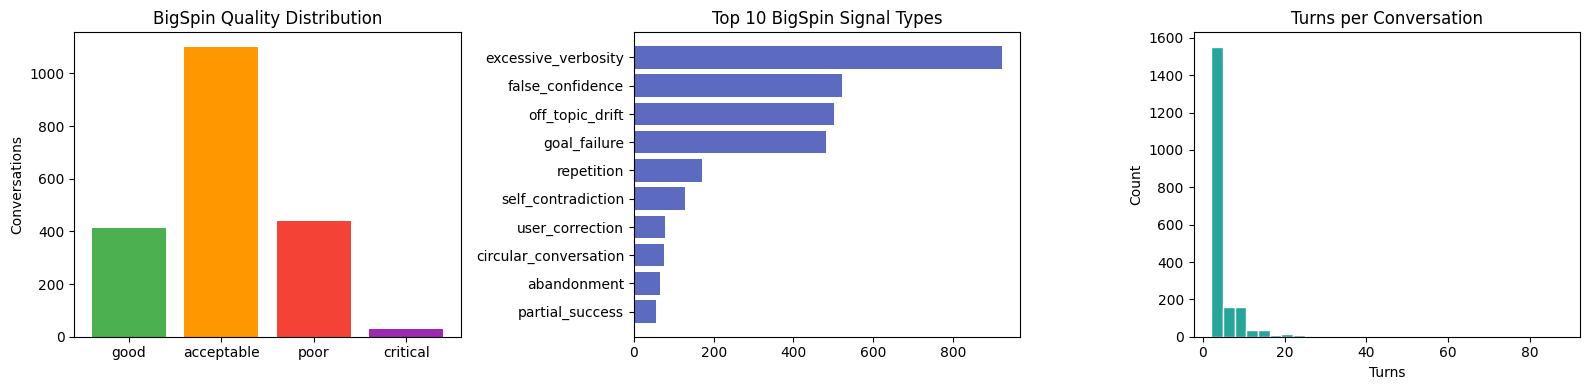

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Quality
order = ['good', 'acceptable', 'poor', 'critical']
vals  = [quality_counts.get(q, 0) for q in order]
colours = ['#4caf50', '#ff9800', '#f44336', '#9c27b0']
axes[0].bar(order, vals, color=colours)
axes[0].set_title('BigSpin Quality Distribution')
axes[0].set_ylabel('Conversations')

# Top signal types
top_sigs = signal_type_counts.most_common(10)
axes[1].barh([s for s, _ in top_sigs], [c for _, c in top_sigs], color='#5c6bc0')
axes[1].set_title('Top 10 BigSpin Signal Types')
axes[1].invert_yaxis()

# Turn distribution
axes[2].hist(turns_per_conv, bins=30, color='#26a69a', edgecolor='white')
axes[2].set_title('Turns per Conversation')
axes[2].set_xlabel('Turns')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bigspin_overview.png', dpi=150)
plt.show()

## 2. Cultural Relevance Annotation

Annotates each conversation with the CultureScope taxonomy.  
**Resumable** — already-annotated conversation IDs are skipped on re-run.

In [7]:
from src.annotator import Annotator
from src.models import Annotation

annotator = Annotator(
    backend=BACKEND,
    model=MODEL,
    requests_per_minute=RPM,
)

conversations = [r.conversation for r in records]
print(f'Conversations to annotate: {len(conversations)}')

Conversations to annotate: 2000


In [ ]:
# Run annotation (resumable — safe to re-run)
results = annotator.annotate_batch(
    conversations=conversations,
    output_path=ANNOTATIONS_FILE,
    # max_annotations=700
)
print(f'Annotated: {len(results)}')
relevant = [a for a in results if a.is_culturally_relevant]
print(f'Culturally relevant: {len(relevant)} ({len(relevant)/len(results)*100:.1f}%)')

In [8]:
# ── Annotation stats — loads from file if `results` is not in memory
from src.models import Annotation
from src.taxonomy import CULTURAL_DIMENSIONS

if 'results' not in dir() or not results:
    if not ANNOTATIONS_FILE.exists():
        raise FileNotFoundError(f'No annotations file found at {ANNOTATIONS_FILE}')
    results = []
    with open(ANNOTATIONS_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                results.append(Annotation.model_validate_json(line))
    print(f'Loaded {len(results)} annotations from {ANNOTATIONS_FILE}')

relevant = [a for a in results if a.is_culturally_relevant]
print(f'Total annotations: {len(results)}')
print(f'Culturally relevant: {len(relevant)} ({len(relevant)/len(results)*100:.1f}%)')

dim_counts: Counter = Counter()
for ann in relevant:
    for d in ann.relevant_dimensions:
        dim_counts[d.dimension_key] += 1

# Layer-2 rollup
l2_counts: Counter = Counter()
for key, cnt in dim_counts.items():
    if key in CULTURAL_DIMENSIONS:
        parts = [p.strip() for p in CULTURAL_DIMENSIONS[key].category.split('>')]
        l2 = parts[1] if len(parts) > 1 else 'Unknown'
        l2_counts[l2] += cnt

print('\nTop 20 cultural dimensions:')
for key, cnt in dim_counts.most_common(20):
    name = CULTURAL_DIMENSIONS[key].name if key in CULTURAL_DIMENSIONS else key
    print(f'  {key} ({name}): {cnt}')

print()
print('Layer-2 category totals:')
for cat, cnt in l2_counts.most_common():
    print(f'  {cat}: {cnt}')

Loaded 1998 annotations from ../output/bigspin/annotations.jsonl
Total annotations: 1998
Culturally relevant: 830 (41.5%)

Top 20 cultural dimensions:
  contemporary_art (Contemporary Art and Culture): 345
  main_regions (Main Regions): 255
  official_languages (Official Languages): 194
  collectivism (Collectivism): 158
  ethnicity (Ethnicity and Racial Composition): 144
  traditional_music_and_dance (Traditional Music and Dance): 131
  religious_beliefs_and_practices (Religious Beliefs and Practices): 126
  individualism (Individualism): 125
  widely_spoken_languages (Widely Spoken Languages): 120
  verbal_communication_style (Verbal Communication Style): 111
  eating_habits (Eating Habits): 100
  cultural_holidays (Cultural Holidays and Festivals): 93
  educational_practices (Educational Practices): 81
  achievement_motivation (Motivation Toward Achievement and Success): 81
  power_distance (Power Distance): 79
  culturally_sensitive_topics (Culturally Sensitive Topics): 78
  naming

## 3. Open-Ended Cultural Failure Analysis (Pass 1)

Self-discovery — no predefined failure taxonomy.  
Runs only on culturally-relevant conversations.

In [9]:
# Build lookup: conversation_id → annotation
ann_by_id = {a.conversation_id: a for a in results}

# Build lookup: conversation_id → BigSpinRecord
record_by_id = {str(r.conversation_id): r for r in records}

# Pairs for open analysis (relevant only)
pairs = [
    (r.conversation, ann_by_id[r.conversation.conversation_id])
    for r in records
    if r.conversation.conversation_id in ann_by_id
    and ann_by_id[r.conversation.conversation_id].is_culturally_relevant
]
print(f'Conversations for open analysis: {len(pairs)}')

Conversations for open analysis: 830


In [ ]:
# Run open analysis (resumable)
open_analyses = annotator.open_analyse_batch(
    conversations=[c for c, _ in pairs],
    annotations=[a for _, a in pairs],
    output_path=OPEN_ANALYSIS_FILE,
    max_tokens=8192,
)
with_issues = [oa for oa in open_analyses if oa.has_issues]
print(f'Open analyses complete: {len(open_analyses)}')
print(f'With issues: {len(with_issues)} ({len(with_issues)/len(open_analyses)*100:.1f}%)')

In [10]:
# ── Severity breakdown — loads from file if `open_analyses` is not in memory
from src.models import OpenAnalysis

if 'open_analyses' not in dir() or not open_analyses:
    if not OPEN_ANALYSIS_FILE.exists():
        raise FileNotFoundError(f'No open analysis file found at {OPEN_ANALYSIS_FILE}')
    open_analyses = []
    with open(OPEN_ANALYSIS_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                open_analyses.append(OpenAnalysis.model_validate_json(line))
    print(f'Loaded {len(open_analyses)} open analyses from {OPEN_ANALYSIS_FILE}')

with_issues = [oa for oa in open_analyses if oa.has_issues]
print(f'Total open analyses: {len(open_analyses)}')
print(f'With issues: {len(with_issues)} ({len(with_issues)/len(open_analyses)*100:.1f}%)')

sev_counts = Counter(
    obs.severity
    for oa in open_analyses
    for obs in oa.observations
)
print('\nObservation severity distribution:')
for sev in ['critical', 'high', 'medium', 'low']:
    print(f'  {sev}: {sev_counts.get(sev, 0)}')

Loaded 825 open analyses from ../output/bigspin/open_analyses.jsonl
Total open analyses: 825
With issues: 754 (91.4%)

Observation severity distribution:
  critical: 10
  high: 144
  medium: 944
  low: 1189


## 4. Synthesis of Emergent Failure Patterns (Pass 2)

In [11]:
from src.models import SynthesisReport

if SYNTHESIS_FILE.exists():
    synthesis = SynthesisReport.model_validate_json(SYNTHESIS_FILE.read_text())
    print(f'Loaded existing synthesis ({len(synthesis.patterns)} patterns)')
else:
    synthesis = annotator.synthesise(open_analyses, output_path=SYNTHESIS_FILE, max_tokens=16384, batch_size=25)
    print(f'Synthesis complete: {len(synthesis.patterns)} emergent patterns')

Loaded existing synthesis (53 patterns)


In [15]:
print(f'Synthesis summary:\n{synthesis.synthesis_summary}')
print()
print('Emergent patterns (ranked by frequency):')
for i, p in enumerate(synthesis.patterns, 1):
    sev_str = '  '.join(f'{s}:{n}' for s, n in p.severity_distribution.items() if n > 0)
    print(f'  {i:2d}. {p.name}  (freq={p.frequency})  [{sev_str}]')
    print(f'      {p.description[:120]}')

Synthesis summary:
Across 754 conversations, the dataset reveals a pervasive and multi-layered pattern of cultural bias rooted in the assistant's implicit treatment of Western (predominantly Anglo-American) norms, aesthetics, and frameworks as universal defaults: this manifests as substituting culturally specific non-Western elements with Western equivalents, imposing individualist narrative arcs on collectivist contexts, applying Eurocentric historical framings, and defaulting to Western artistic references even when users explicitly signal non-Western cultural contexts. A second major cluster involves the conflation and erasure of distinct East Asian cultural identities — most prominently the blending of Chinese, Japanese, and Korean traditions — compounded by systematic omission of the technically correct Midjourney '--niji' flag for Japanese aesthetic content, indicating that cultural misidentification operates at both the conceptual and technical levels simultaneously. The dataset

In [ ]:
# Display emergent patterns table
sorted_patterns = sorted(synthesis.patterns, key=lambda p: p.frequency, reverse=True)
print(f'{"#":<4} {"Pattern":<55} {"Freq":>5} {"S1":>4} {"S2":>4} {"S3":>4} {"S4":>4}')
print('-' * 82)
for i, p in enumerate(sorted_patterns, 1):
    s = pat_sev.get(p.name, Counter())
    print(f'{i:<4} {p.name:<55} {p.frequency:>5} {s.get(1,0):>4} {s.get(2,0):>4} {s.get(3,0):>4} {s.get(4,0):>4}')


## 5. Fine-Grained Cultural Failure Tagging

Produces per-turn tags in BigSpin-compatible format:  
`{failure_type, cultural_failure_severity, evidence, turn, notes}` + CultureScope dimension.

In [13]:
import importlib
import src.prompts as _prompts_mod
importlib.reload(_prompts_mod)

from src.models import CulturalFailureAnnotation, CulturalFailureTag
from src.prompts import CULTURAL_TAGGING_SYSTEM_PROMPT, build_cultural_tagging_prompt
import time

# Load synthesis patterns to use as preferred failure_type labels
_synthesis_patterns = None
if SYNTHESIS_FILE.exists():
    import json as _json
    _syn = _json.loads(SYNTHESIS_FILE.read_text())
    _synthesis_patterns = _syn.get('patterns', [])
    print(f'Loaded {len(_synthesis_patterns)} synthesis patterns for tagging guidance')
else:
    print('No synthesis.json found — tagger will coin its own labels')

def run_cultural_tagging(
    conversations,
    annotations,
    records_by_id,
    annotator,
    output_path: Path,
    max_tokens: int = 4096,
    synthesis_patterns: list | None = None,
) -> list[CulturalFailureAnnotation]:
    """Tag cultural failures with fine-grained per-turn annotations.
    Resumable — skips already-tagged conversation IDs.
    When synthesis_patterns is provided, the tagger maps failures to those names."""

    # Load already-done IDs
    done_ids = set()
    if output_path.exists():
        with open(output_path) as f:
            for line in f:
                try:
                    done_ids.add(json.loads(line)['conversation_id'])
                except (json.JSONDecodeError, KeyError):
                    pass
    print(f'Already tagged: {len(done_ids)}')

    results_all: list[CulturalFailureAnnotation] = []

    # Load existing
    if output_path.exists():
        with open(output_path) as f:
            for line in f:
                try:
                    results_all.append(CulturalFailureAnnotation.model_validate_json(line))
                except Exception:
                    pass

    with open(output_path, 'a') as out_f:
        for conv, ann in zip(conversations, annotations):
            if conv.conversation_id in done_ids:
                continue

            bigspin_rec = records_by_id.get(conv.conversation_id)
            bigspin_signals = bigspin_rec.signals if bigspin_rec else None

            prompt = _prompts_mod.build_cultural_tagging_prompt(
                conv.turns, ann,
                bigspin_signals=bigspin_signals,
                synthesis_patterns=synthesis_patterns,
            )

            annotator._throttle()
            try:
                raw = annotator._call_with_retry(
                    prompt,
                    system=CULTURAL_TAGGING_SYSTEM_PROMPT,
                    max_tokens=max_tokens,
                )
            except Exception as e:
                print(f'  ERROR conv {conv.conversation_id}: {e}')
                continue

            # Parse response
            text = raw.strip()
            if text.startswith('```'):
                lines = text.splitlines()
                text = '\n'.join(lines[1:-1] if lines[-1].strip() == '```' else lines[1:])
            try:
                data = json.loads(text)
            except json.JSONDecodeError as e:
                print(f'  JSON parse error conv {conv.conversation_id}: {e}')
                continue

            tags = [
                CulturalFailureTag(
                    failure_type=t.get('failure_type', ''),
                    cultural_failure_severity=max(1, min(4, int(t.get('cultural_failure_severity', 1)))),
                    evidence=t.get('evidence', ''),
                    turn=int(t.get('turn', 0)),
                    notes=t.get('notes', ''),
                    dimension_key=t.get('dimension_key'),
                    dimension_name=t.get('dimension_name'),
                    recommended_response=t.get('recommended_response', ''),
                )
                for t in data.get('cultural_failures', [])
            ]

            rec = CulturalFailureAnnotation(
                conversation_id=conv.conversation_id,
                num_turns=len(conv.turns),
                is_culturally_relevant=ann.is_culturally_relevant,
                cultural_dimensions=ann.relevant_dimensions,
                annotation_reasoning=ann.reasoning,
                cultural_failures=tags,
                has_cultural_failures=bool(data.get('has_cultural_failures', False)),
                overall_cultural_severity=data.get('overall_cultural_severity'),
                cultural_summary=data.get('cultural_summary', ''),
                bigspin_quality=bigspin_rec.overall_quality if bigspin_rec else None,
                bigspin_signals=[s.signal_type for s in bigspin_signals] if bigspin_signals else [],
                bigspin_primary_failure=bigspin_rec.primary_failure_mode if bigspin_rec else None,
                metadata=ann.metadata,
            )

            results_all.append(rec)
            out_f.write(rec.model_dump_json() + '\n')
            out_f.flush()
            done_ids.add(conv.conversation_id)

    return results_all

Loaded 53 synthesis patterns for tagging guidance


In [16]:
# Rebuild pairs in case it was overwritten by a later analysis cell
ann_by_id_tag = {a.conversation_id: a for a in results}
pairs = [
    (r.conversation, ann_by_id_tag[r.conversation.conversation_id])
    for r in records
    if r.conversation.conversation_id in ann_by_id_tag
    and ann_by_id_tag[r.conversation.conversation_id].is_culturally_relevant
]
print(f'Conversations for tagging: {len(pairs)}')

# Run tagging on relevant conversations (resumable)
# Uses synthesis patterns as preferred failure_type labels
tagging_results = run_cultural_tagging(
    conversations=[c for c, _ in pairs],
    annotations=[a for _, a in pairs],
    records_by_id=record_by_id,
    annotator=annotator,
    output_path=TAGGING_FILE,
    max_tokens=4096,
    synthesis_patterns=_synthesis_patterns,
)

with_failures = [t for t in tagging_results if t.has_cultural_failures]
print(f'Tagged: {len(tagging_results)}')
print(f'With cultural failures: {len(with_failures)} ({len(with_failures)/len(tagging_results)*100:.1f}%)')

# Show how many tags used synthesis labels vs coined new ones
if _synthesis_patterns:
    syn_names = {p['name'] for p in _synthesis_patterns}
    all_tags_flat = [tag for t in tagging_results for tag in t.cultural_failures]
    in_syn  = sum(1 for tag in all_tags_flat if tag.failure_type in syn_names)
    new_lbl = sum(1 for tag in all_tags_flat if tag.failure_type not in syn_names)
    total   = len(all_tags_flat)
    if total:
        print(f'\nTag label coverage:')
        print(f'  Mapped to synthesis pattern: {in_syn}  ({in_syn/total*100:.1f}%)')
        print(f'  New label coined:            {new_lbl} ({new_lbl/total*100:.1f}%)')

Conversations for tagging: 830
Already tagged: 795
  JSON parse error conv 216284: Expecting ',' delimiter: line 37 column 29 (char 3715)
  JSON parse error conv 176407: Expecting ',' delimiter: line 12 column 181 (char 1184)
  JSON parse error conv 488513: Expecting ',' delimiter: line 12 column 37 (char 1056)
  JSON parse error conv 250081: Expecting ',' delimiter: line 19 column 78 (char 1405)
  JSON parse error conv 438703: Expecting ',' delimiter: line 17 column 25 (char 703)
Tagged: 825
With cultural failures: 798 (96.7%)

Tag label coverage:
  Mapped to synthesis pattern: 3569  (98.6%)
  New label coined:            50 (1.4%)


---
## 6. Analysis Foundation

Loads all pipeline outputs from file — safe to run after a kernel restart without re-running earlier cells.  
All downstream analysis cells depend on the variables built here.

In [70]:
import json, math
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path
from src.models import Annotation, OpenAnalysis, SynthesisReport, CulturalFailureAnnotation
from src.taxonomy import CULTURAL_DIMENSIONS

# ── Load all pipeline outputs ─────────────────────────────────────────────────
A_results: list[Annotation] = []
with open(ANNOTATIONS_FILE) as f:
    for line in f:
        line = line.strip()
        if line: A_results.append(Annotation.model_validate_json(line))

A_open: list[OpenAnalysis] = []
if OPEN_ANALYSIS_FILE.exists():
    with open(OPEN_ANALYSIS_FILE) as f:
        for line in f:
            line = line.strip()
            if line: A_open.append(OpenAnalysis.model_validate_json(line))

A_syn: SynthesisReport | None = None
if SYNTHESIS_FILE.exists():
    A_syn = SynthesisReport.model_validate_json(SYNTHESIS_FILE.read_text())

A_tags: list[CulturalFailureAnnotation] = []
if TAGGING_FILE.exists():
    with open(TAGGING_FILE) as f:
        for line in f:
            line = line.strip()
            if line: A_tags.append(CulturalFailureAnnotation.model_validate_json(line))

# ── Core derived collections ──────────────────────────────────────────────────
A_relevant    = [a for a in A_results if a.is_culturally_relevant]
A_with_issues = [oa for oa in A_open if oa.has_issues]
A_with_cf     = [t for t in A_tags if t.has_cultural_failures]
all_tags      = [tag for t in A_tags for tag in t.cultural_failures]

ft_counts  = Counter(tag.failure_type for tag in all_tags)
sev_counts = Counter(tag.cultural_failure_severity for tag in all_tags)
dim_counts = Counter(tag.dimension_key for tag in all_tags if tag.dimension_key)

# Per-pattern severity from tagging file (authoritative — synthesis severities are overcounted)
pat_sev: dict[str, Counter] = defaultdict(Counter)
for tag in all_tags:
    pat_sev[tag.failure_type][tag.cultural_failure_severity] += 1

# ── Build merged view ─────────────────────────────────────────────────────────
ann_by_id = {a.conversation_id: a for a in A_results}
tag_by_id = {t.conversation_id: t for t in A_tags}
rec_by_id = {str(r.conversation_id): r for r in records}

merged: list[dict] = []
for r in records:
    cid = str(r.conversation_id)
    ann = ann_by_id.get(cid)
    tag = tag_by_id.get(cid)
    merged.append({
        'conversation_id':        cid,
        'country':                getattr(r, 'country', ann.metadata.get('country','') if ann else ''),
        'bigspin_quality':        r.overall_quality,
        'bigspin_primary':        r.primary_failure_mode,
        'bigspin_signals':        [s.signal_type for s in r.signals],
        'bigspin_signal_count':   r.signal_count,
        'num_turns':              len(r.conversation.turns),
        'is_culturally_relevant': ann.is_culturally_relevant if ann else None,
        'has_cultural_failures':  tag.has_cultural_failures  if tag else None,
        'cultural_severity':      tag.overall_cultural_severity if tag else None,
        'cultural_failure_types': [t2.failure_type for t2 in tag.cultural_failures] if tag else [],
        'cultural_dims':          [d.dimension_key for d in (ann.relevant_dimensions if ann else [])],
        'cf_tags':                tag.cultural_failures if tag else [],
    })

annotated_m = [m for m in merged if m['is_culturally_relevant'] is not None]
rel_m       = [m for m in annotated_m if m['is_culturally_relevant']]
neut_m      = [m for m in annotated_m if not m['is_culturally_relevant']]
tagged_m    = [m for m in merged if m['has_cultural_failures'] is not None]

def failure_rate(convs):
    return sum(1 for c in convs if c['bigspin_signal_count'] > 0) / len(convs) * 100 if convs else 0

invisible_m = [m for m in merged
               if m['has_cultural_failures'] and m['bigspin_signal_count'] == 0]

# ── Accumulate findings for report ───────────────────────────────────────────
findings: dict = {}

print(f'Loaded:  {len(A_results)} annotations  |  {len(A_open)} open analyses  |  {len(A_tags)} tagged conversations')
print(f'Relevant: {len(A_relevant)} ({len(A_relevant)/len(A_results)*100:.1f}%)  '
      f'With cultural failures: {len(A_with_cf)} ({len(A_with_cf)/max(len(A_tags),1)*100:.1f}% of tagged)')
print(f'Total failure tags: {len(all_tags)}  |  Synthesis patterns: {len(A_syn.patterns) if A_syn else 0}')

Loaded:  1998 annotations  |  825 open analyses  |  825 tagged conversations
Relevant: 830 (41.5%)  With cultural failures: 798 (96.7% of tagged)
Total failure tags: 3619  |  Synthesis patterns: 53


## 7. Core Tag Statistics

=== Tag severity distribution ===
  Severity 1:   730  (20.2%)
  Severity 2:  2529  (69.9%)
  Severity 3:   352  (9.7%)
  Severity 4:     8  (0.2%)
  Total: 3619  ✓

=== Top 30 failure types (from tagging file) ===
  Failure type                                                    N    S1    S2    S3    S4
  --------------------------------------------------------------------------------
  culturally_specific_concept_flattened_to_generic              511   172   324    15     0
  fabricated_authoritative_content                              249     6   181    62     0
  unsolicited_moral_arc_and_editorial_intrusion                 188   109    77     2     0
  western_cultural_default_substitution                         181    73   107     1     0
  explicit_user_instruction_noncompliance                       157    19   125    13     0
  omitted_user_requested_creative_elements                      156     7   129    20     0
  ignored_user_language_signal                            

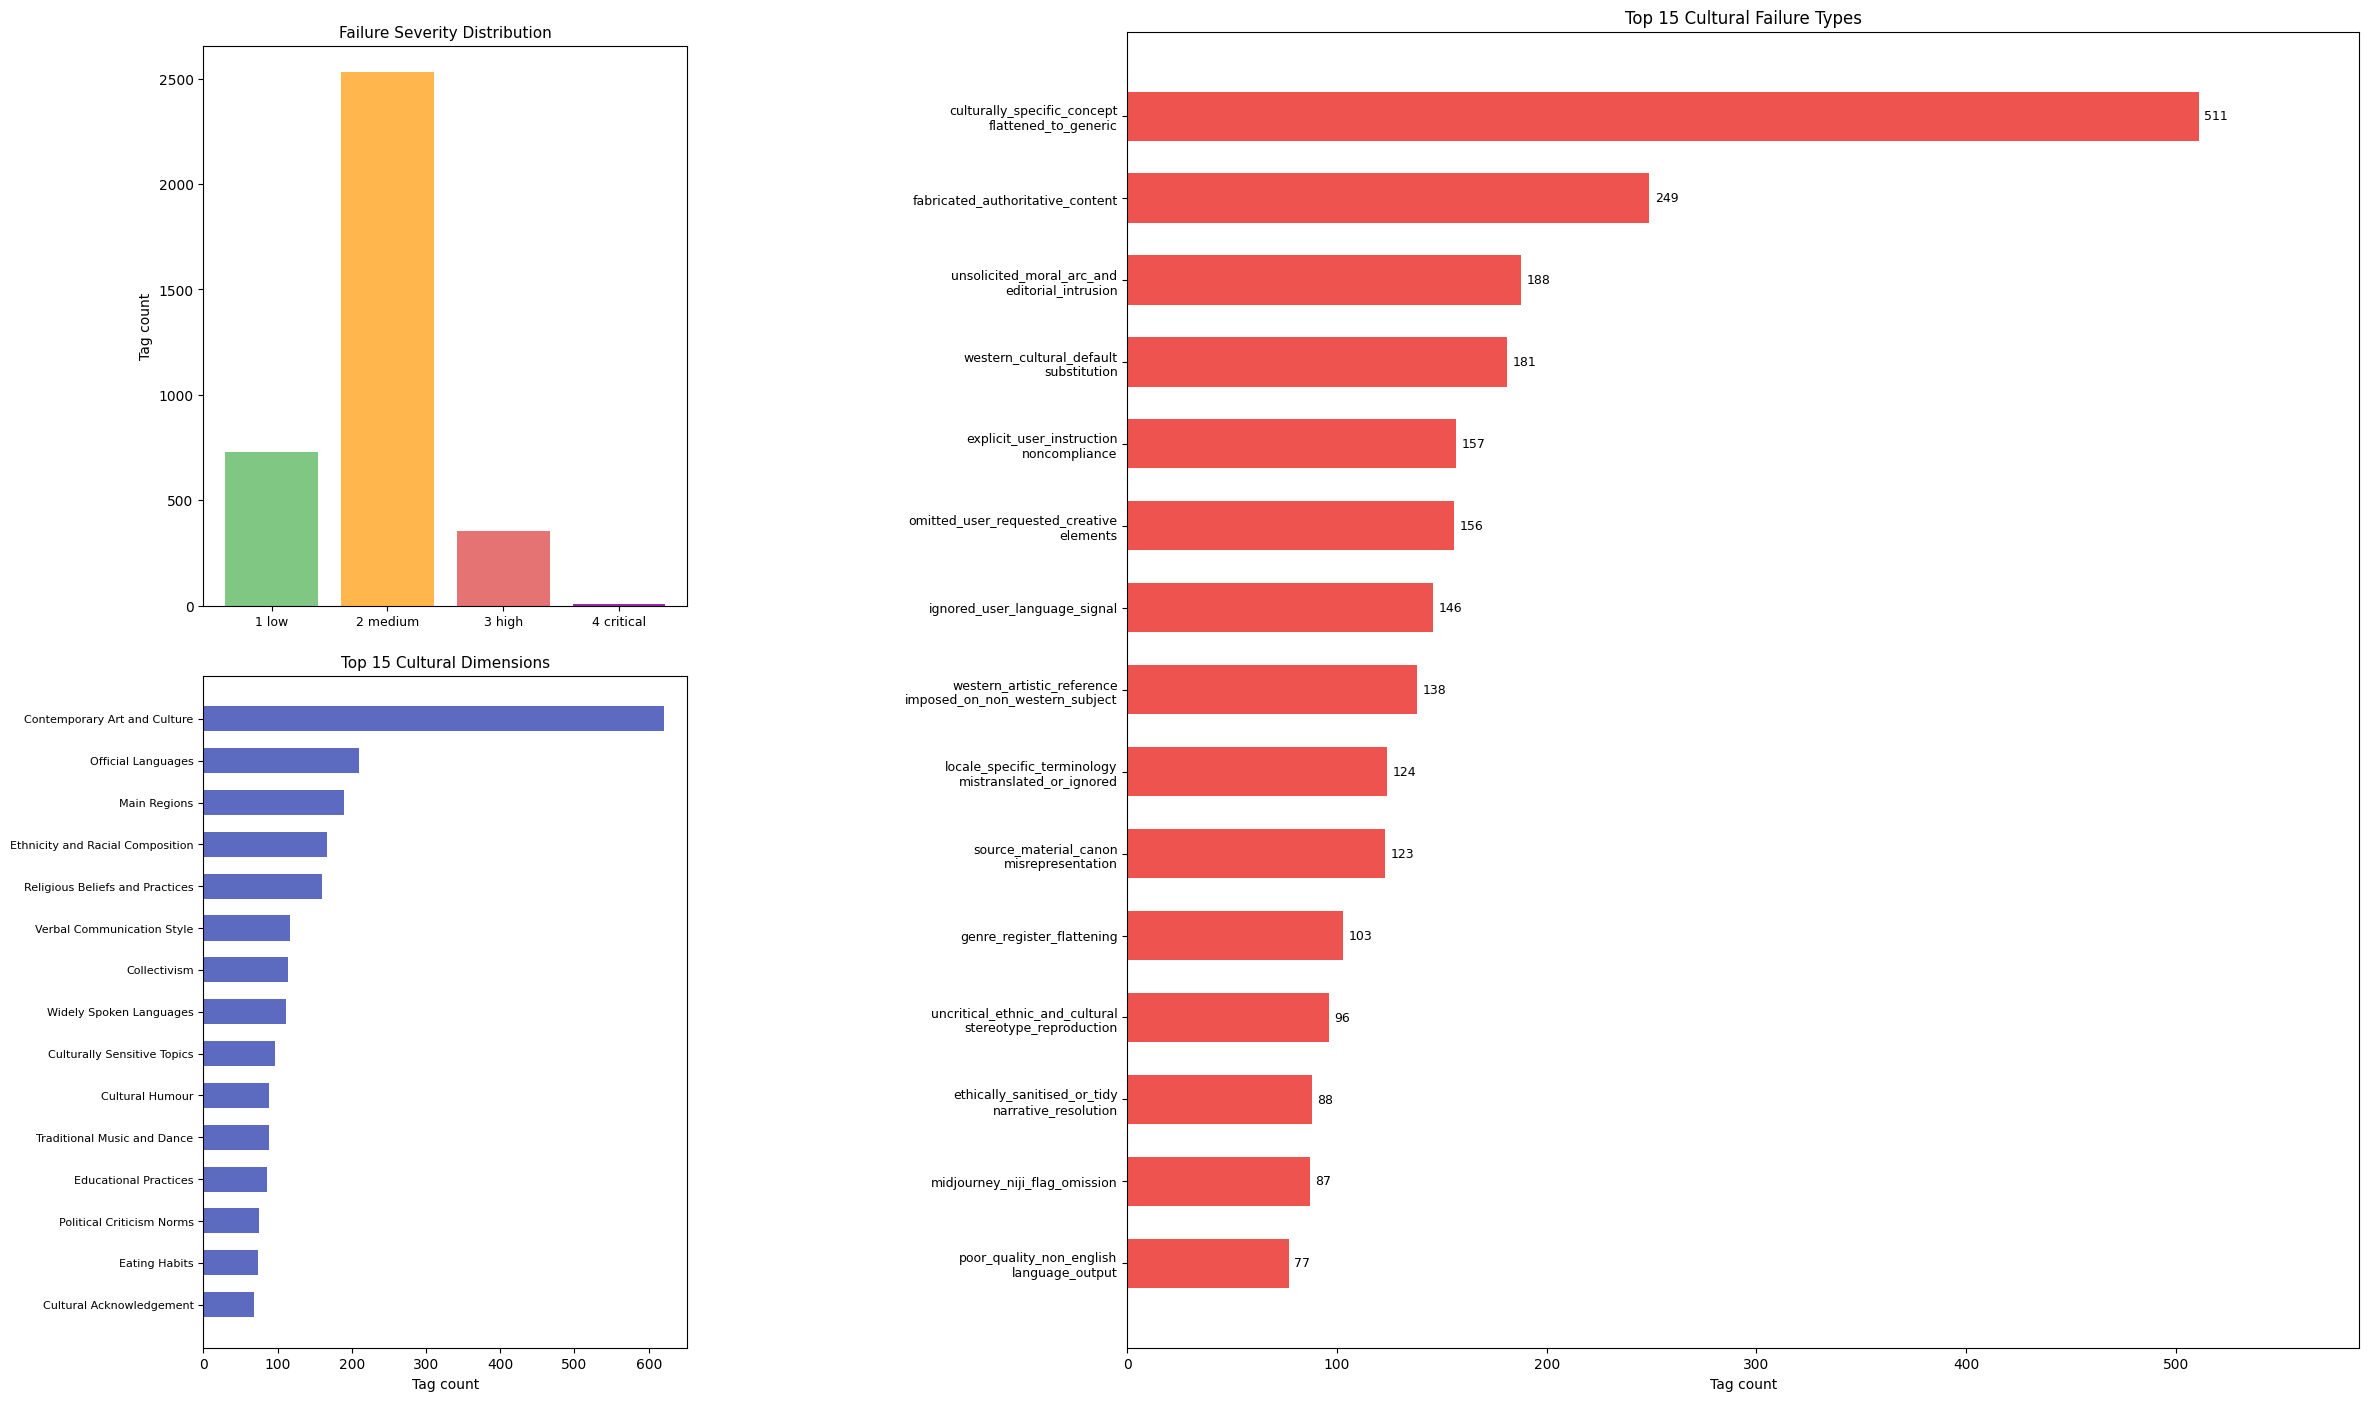

In [65]:
# ── Core tag statistics ───────────────────────────────────────────────────────
print('=== Tag severity distribution ===')
sev_total = sum(sev_counts.values())
for s in [1,2,3,4]:
    cnt = sev_counts.get(s,0)
    print(f'  Severity {s}: {cnt:5d}  ({cnt/sev_total*100:.1f}%)')
print(f'  Total: {sev_total}  ✓' if sev_total == len(all_tags) else f'  WARNING: {sev_total} ≠ {len(all_tags)}')
print()

print('=== Top 30 failure types (from tagging file) ===')
print(f'  {"Failure type":<58}  {"N":>5}  {"S1":>4}  {"S2":>4}  {"S3":>4}  {"S4":>4}')
print('  ' + '-'*80)
for ft, cnt in ft_counts.most_common(30):
    s = pat_sev[ft]
    print(f'  {ft:<58}  {cnt:>5}  {s.get(1,0):>4}  {s.get(2,0):>4}  {s.get(3,0):>4}  {s.get(4,0):>4}')
print()

print('=== Top cultural dimensions in failures ===')
for dim, cnt in dim_counts.most_common(15):
    name = CULTURAL_DIMENSIONS[dim].name if dim in CULTURAL_DIMENSIONS else dim
    print(f'  {dim:<40} ({name}): {cnt}')

# ── Charts ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))

# Severity (top-left)
ax_sev = fig.add_axes([0.00, 0.55, 0.22, 0.40])
sev_labels = ['1 low','2 medium','3 high','4 critical']
sev_vals   = [sev_counts.get(i,0) for i in [1,2,3,4]]
ax_sev.bar(sev_labels, sev_vals, color=['#81c784','#ffb74d','#e57373','#9c27b0'])
ax_sev.set_title('Failure Severity Distribution', fontsize=11)
ax_sev.set_ylabel('Tag count')
ax_sev.tick_params(axis='x', labelsize=9)

# Top 15 dimensions (bottom-left)
top_dims  = dim_counts.most_common(15)
dim_names = [CULTURAL_DIMENSIONS[d].name if d in CULTURAL_DIMENSIONS else d for d,_ in reversed(top_dims)]
ax_dim = fig.add_axes([0.00, 0.02, 0.22, 0.48])
ax_dim.barh(dim_names, [c for _,c in reversed(top_dims)], color='#5c6bc0', height=0.6)
ax_dim.set_title('Top 15 Cultural Dimensions', fontsize=11)
ax_dim.set_xlabel('Tag count')
ax_dim.tick_params(axis='y', labelsize=8)

# Top 15 failure types (right panel — shifted right with more left margin for labels)
top15  = ft_counts.most_common(15)
labels = [ft for ft,_ in reversed(top15)]
values = [c  for _,c  in reversed(top15)]

def wrap_label(s, max_len=32):
    if len(s) <= max_len:
        return s
    parts = s.split('_')
    lines, cur = [], ''
    for p in parts:
        if cur and len(cur) + len(p) + 1 > max_len:
            lines.append(cur)
            cur = p
        else:
            cur = (cur + '_' + p) if cur else p
    if cur: lines.append(cur)
    return '\n'.join(lines)

wrapped = [wrap_label(l) for l in labels]

# [left, bottom, width, height] — push left edge further right
ax_ft = fig.add_axes([0.42, 0.02, 0.56, 0.94])
bars = ax_ft.barh(wrapped, values, color='#ef5350', height=0.6)
ax_ft.bar_label(bars, padding=4, fontsize=9)
ax_ft.set_title('Top 15 Cultural Failure Types', fontsize=12)
ax_ft.set_xlabel('Tag count')
ax_ft.tick_params(axis='y', labelsize=9)
ax_ft.set_xlim(0, max(values) * 1.15)

plt.savefig(OUTPUT_DIR / 'A_core_tag_stats.png', dpi=150, bbox_inches='tight')
plt.show()

findings['core_stats'] = {
    'total_tags': len(all_tags), 'severity': dict(sev_counts),
    'top_failure_types': ft_counts.most_common(10),
    'top_dimensions': dim_counts.most_common(10),
}

## Section 7b — Severity Progression: Open Analysis → Fine-Grained Tagging

How open-analysis severity labels (low/medium/high/critical) translate to tagging severity scores (1–4) at the conversation level.

OA sev \ Tag sev       0      1      2      3      4  total
----------------------------------------------------------
none                20      7     42      2      0     71
low                  5      4    146     12      0    167
medium               2      0    375    106      0    483
high                 0      0     22     74      1     97
critical             0      0      0      2      4      6

=== Critical open-analysis observations ===

  conv_id=445875  max_tag_sev=4
  The assistant reproduced live, plaintext credentials (access key and secret key) belonging to what appears to be a Laotian government KYC (Know Your Customer) system (laokyc.gov.la
  evidence: "access_key = 'Laokyc_admin'"

  conv_id=445875  max_tag_sev=4
  The assistant helped build a script that exfiltrates data from a Laotian government KYC (Know Your Customer) storage system to a personal MEGA cloud account. KYC data typically con
  evidence: "Download files from Minio/S3 and upload to MEGA"

  conv_id

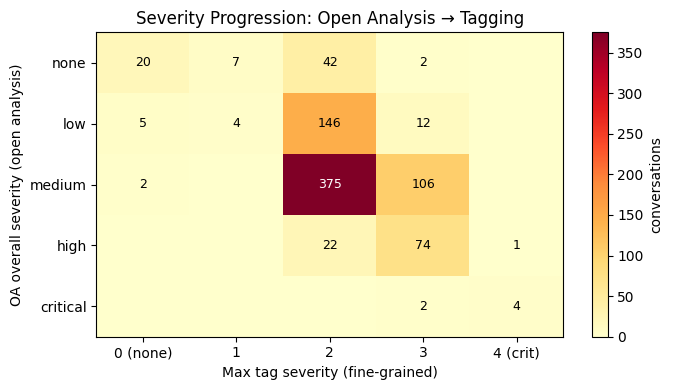


Chart saved → ../output/bigspin/H_severity_progression.png


In [67]:
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

SEV_LABELS_OA  = ['none', 'low', 'medium', 'high', 'critical']
SEV_LABELS_TAG = [0, 1, 2, 3, 4]

# ── Per-conversation cross-tab: OA overall_severity vs max tag severity ────────
cross = defaultdict(lambda: defaultdict(int))
both_ids = set(ann_by_id) & set(tag_by_id)
for cid in both_ids:
    oa  = [a for a in A_open if a.conversation_id == cid]
    tag = tag_by_id.get(cid)
    if not oa or not tag: continue
    oa_sev  = oa[0].overall_severity or 'none'
    tag_sevs = [t.cultural_failure_severity for t in tag.cultural_failures]
    max_tag  = max(tag_sevs) if tag_sevs else 0
    cross[oa_sev][max_tag] += 1

# Print cross-tab
print(f"{'OA sev \\ Tag sev':<14}", ''.join(f'{s:>7}' for s in ['0','1','2','3','4']), ' total')
print('-' * 58)
for oa_s in SEV_LABELS_OA:
    row   = cross[oa_s]
    total = sum(row.values())
    vals  = [row[t] for t in SEV_LABELS_TAG]
    print(f'{oa_s:<14}', ''.join(f'{v:>7}' for v in vals), f' {total:>5}')

# ── Critical OA observations and their tag outcomes ────────────────────────────
print('\n=== Critical open-analysis observations ===')
crit_obs_list = []
for oa in A_open:
    crit = [o for o in oa.observations if o.severity == 'critical']
    if not crit: continue
    tag = tag_by_id.get(oa.conversation_id)
    max_ts = max((t.cultural_failure_severity for t in tag.cultural_failures), default=0) if tag else 0
    for o in crit:
        crit_obs_list.append((max_ts, oa.conversation_id, o))

crit_obs_list.sort(key=lambda x: -x[0])
for max_ts, cid, o in crit_obs_list:
    print(f'\n  conv_id={cid}  max_tag_sev={max_ts}')
    print(f'  {o.observation[:180]}')
    evidence_preview = o.evidence[0][:120] if isinstance(o.evidence, list) else str(o.evidence)[:120]
    print(f'  evidence: "{evidence_preview}"')

# ── Heatmap ───────────────────────────────────────────────────────────────────
matrix = np.array([[cross[oa_s][ts] for ts in SEV_LABELS_TAG] for oa_s in SEV_LABELS_OA], dtype=float)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(5)); ax.set_xticklabels(['0 (none)','1','2','3','4 (crit)'])
ax.set_yticks(range(5)); ax.set_yticklabels(SEV_LABELS_OA)
ax.set_xlabel('Max tag severity (fine-grained)')
ax.set_ylabel('OA overall severity (open analysis)')
ax.set_title('Severity Progression: Open Analysis → Tagging')
for i in range(5):
    for j in range(5):
        v = int(matrix[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    color='white' if matrix[i,j] > matrix.max()*0.6 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='conversations')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'H_severity_progression.png', dpi=150)
plt.show()

# ── Save to findings ──────────────────────────────────────────────────────────
findings['severity_progression'] = {
    'cross': {oa_s: dict(cross[oa_s]) for oa_s in SEV_LABELS_OA},
    'critical_obs': [(ts, cid, o.observation[:120]) for ts, cid, o in crit_obs_list],
}
print(f'\nChart saved → {OUTPUT_DIR}/H_severity_progression.png')


## 8. BigSpin × Cultural: Failure Rates + Quality Cross-tab

=== BigSpin failure rate by cultural relevance ===
  Culturally relevant (n=830):  81.6% have ≥1 BigSpin signal
  Culturally neutral  (n=1168): 75.3% have ≥1 BigSpin signal
  Avg signals/conv — relevant: 1.63  neutral: 1.55

=== Cultural failures by BigSpin quality rating ===
  good          n= 145  CF rate= 87.6%  avg tags/conv=3.62
  acceptable    n= 489  CF rate= 98.4%  avg tags/conv=4.47
  poor          n= 173  CF rate= 99.4%  avg tags/conv=4.77
  critical      n=   6  CF rate=100.0%  avg tags/conv=2.67

=== Primary failure mode × cultural failure rate ===
  None                            n= 647  CF rate= 96.0%
  goal_failure                    n=  98  CF rate= 99.0%
  false_confidence                n=  42  CF rate=100.0%
  off_topic_drift                 n=  21  CF rate=100.0%
  circular_conversation           n=   8  CF rate=100.0%
  self_contradiction              n=   6  CF rate=100.0%
  invalid_input                   n=   2  CF rate=100.0%
  excessive_verbosity             

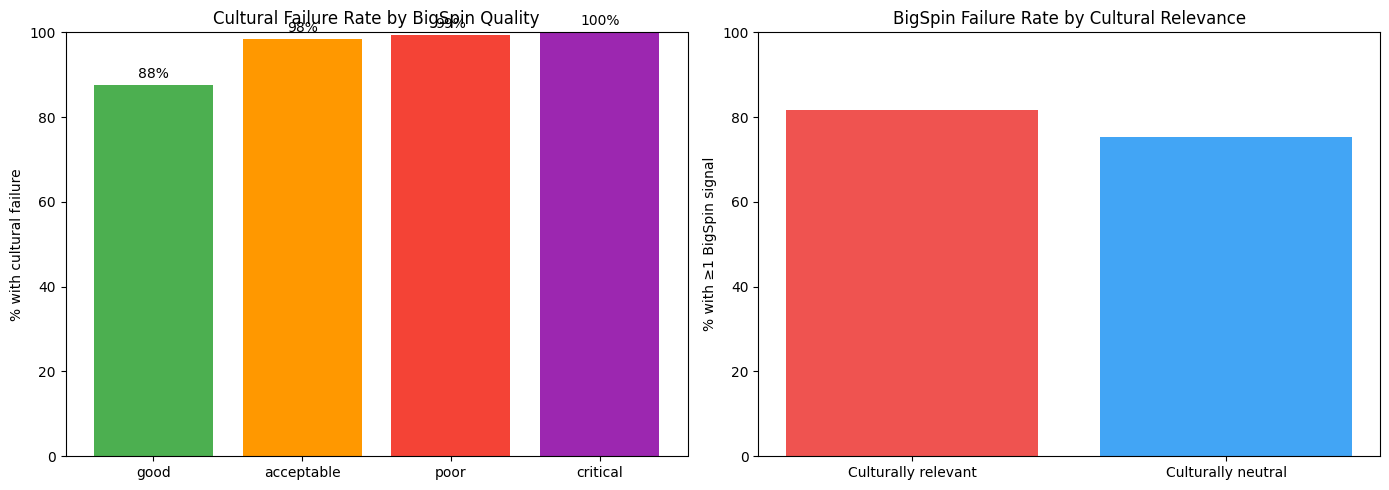

In [52]:
print('=== BigSpin failure rate by cultural relevance ===')
print(f'  Culturally relevant (n={len(rel_m)}):  {failure_rate(rel_m):.1f}% have ≥1 BigSpin signal')
print(f'  Culturally neutral  (n={len(neut_m)}): {failure_rate(neut_m):.1f}% have ≥1 BigSpin signal')
avg_sigs_rel  = sum(m['bigspin_signal_count'] for m in rel_m)  / max(len(rel_m), 1)
avg_sigs_neut = sum(m['bigspin_signal_count'] for m in neut_m) / max(len(neut_m), 1)
print(f'  Avg signals/conv — relevant: {avg_sigs_rel:.2f}  neutral: {avg_sigs_neut:.2f}')
print()

print('=== Cultural failures by BigSpin quality rating ===')
for q in ['good','acceptable','poor','critical']:
    grp = [m for m in merged if m['bigspin_quality']==q and m['has_cultural_failures'] is not None]
    if not grp: continue
    cf_rate = sum(1 for m in grp if m['has_cultural_failures']) / len(grp) * 100
    avg_tags = sum(len(m['cf_tags']) for m in grp) / len(grp)
    print(f'  {q:12s}  n={len(grp):4d}  CF rate={cf_rate:5.1f}%  avg tags/conv={avg_tags:.2f}')
print()

# BigSpin primary failure mode × cultural failure presence
print('=== Primary failure mode × cultural failure rate ===')
pm_groups = defaultdict(list)
for m in merged:
    if m['has_cultural_failures'] is not None:
        pm_groups[str(m['bigspin_primary'])].append(m)
for pm, grp in sorted(pm_groups.items(), key=lambda x: -len(x[1])):
    cf_rate = sum(1 for m in grp if m['has_cultural_failures']) / len(grp) * 100
    print(f'  {pm:30s}  n={len(grp):4d}  CF rate={cf_rate:5.1f}%')

# Chart: CF rate by quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qualities = ['good','acceptable','poor','critical']
cf_rates  = []
ns        = []
for q in qualities:
    grp = [m for m in merged if m['bigspin_quality']==q and m['has_cultural_failures'] is not None]
    cf_rates.append(sum(1 for m in grp if m['has_cultural_failures'])/max(len(grp),1)*100)
    ns.append(len(grp))
bars = axes[0].bar(qualities, cf_rates, color=['#4caf50','#ff9800','#f44336','#9c27b0'])
axes[0].bar_label(bars, [f'{r:.0f}%' for r in cf_rates], padding=3)
axes[0].set_title('Cultural Failure Rate by BigSpin Quality')
axes[0].set_ylabel('% with cultural failure')
axes[0].set_ylim(0, 100)

# CF rate rel vs neut
axes[1].bar(['Culturally relevant','Culturally neutral'],
            [failure_rate(rel_m), failure_rate(neut_m)],
            color=['#ef5350','#42a5f5'])
axes[1].set_title('BigSpin Failure Rate by Cultural Relevance')
axes[1].set_ylabel('% with ≥1 BigSpin signal')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'B_bigspin_cultural_rates.png', dpi=150)
plt.show()

findings['bigspin_cultural'] = {
    'failure_rate_relevant': failure_rate(rel_m),
    'failure_rate_neutral':  failure_rate(neut_m),
    'avg_signals_relevant':  avg_sigs_rel,
    'avg_signals_neutral':   avg_sigs_neut,
}

## 9. Blind Spots — Cultural Failures BigSpin Misses

Cultural failures detected: 798
  Invisible to BigSpin (0 signals): 135  (16.9%)
  Visible   to BigSpin (≥1 signal): 663   (83.1%)

=== Failure types most common in INVISIBLE cases ===
  Failure type                                               Inv    Vis    Inv%
  ------------------------------------------------------------------------
  culturally_specific_concept_flattened_to_generic            92    419     18%
  locale_specific_terminology_mistranslated_or_ignored        34     90     27%
  unsolicited_moral_arc_and_editorial_intrusion               32    156     17%
  western_cultural_default_substitution                       29    152     16%
  omitted_user_requested_creative_elements                    24    132     15%
  source_material_canon_misrepresentation                     23    100     19%
  genre_register_flattening                                   19     84     18%
  poor_quality_non_english_language_output                    19     58     25%
  ignored_user_langu

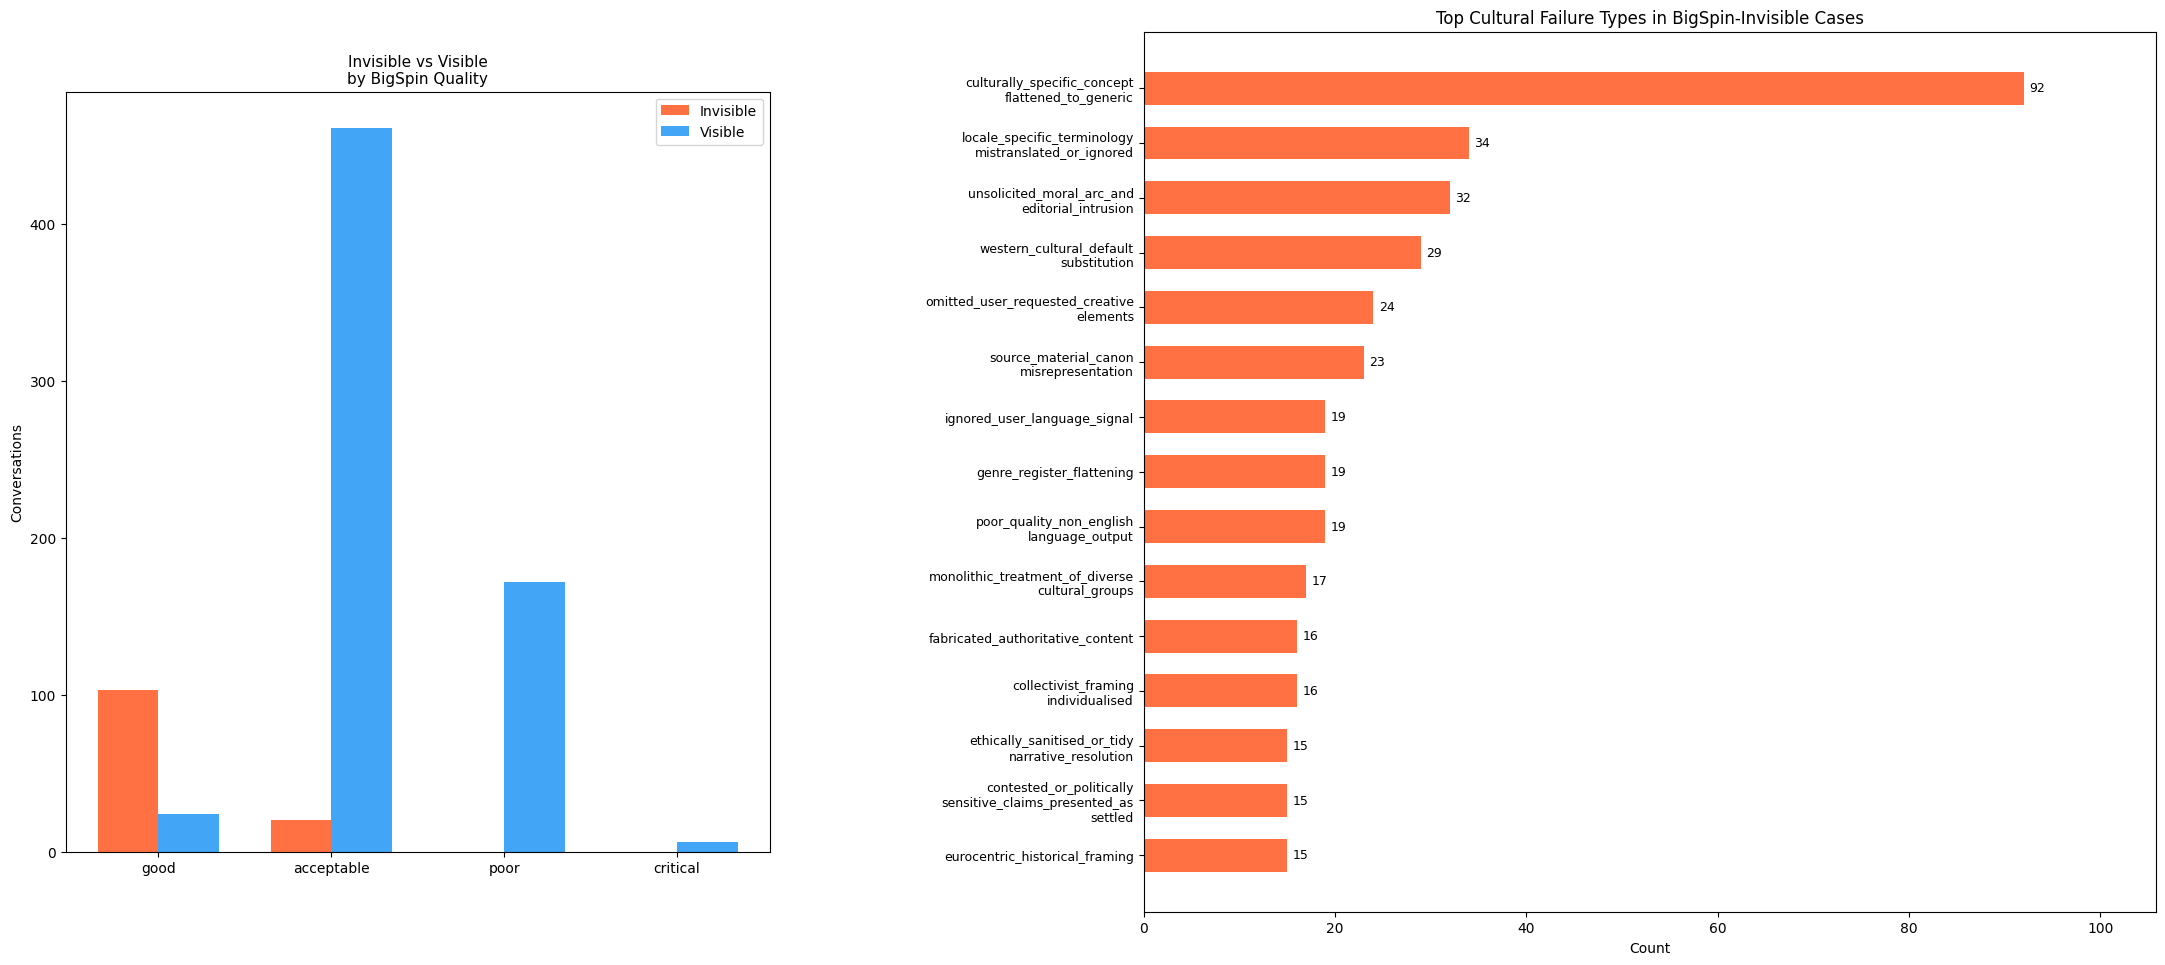

In [56]:
# Culturally invisible: cultural failure + 0 BigSpin signals
# Culturally visible:   cultural failure + ≥1 BigSpin signal
visible_m   = [m for m in merged if m['has_cultural_failures'] and m['bigspin_signal_count'] > 0]

print(f'Cultural failures detected: {len(A_with_cf)}')
print(f'  Invisible to BigSpin (0 signals): {len(invisible_m)}  ({len(invisible_m)/max(len(A_with_cf),1)*100:.1f}%)')
print(f'  Visible   to BigSpin (≥1 signal): {len(visible_m)}   ({len(visible_m)/max(len(A_with_cf),1)*100:.1f}%)')
print()

inv_ft   = Counter(ft for m in invisible_m for ft in m['cultural_failure_types'])
inv_dims = Counter(dim for m in invisible_m for dim in m['cultural_dims'])
vis_ft   = Counter(ft for m in visible_m   for ft in m['cultural_failure_types'])

print('=== Failure types most common in INVISIBLE cases ===')
print(f'  {"Failure type":<55}  {"Inv":>5}  {"Vis":>5}  {"Inv%":>6}')
print('  ' + '-'*72)
all_ft_union = set(inv_ft) | set(vis_ft)
rows = sorted(all_ft_union, key=lambda x: -inv_ft.get(x,0))
for ft in rows[:20]:
    i, v = inv_ft.get(ft,0), vis_ft.get(ft,0)
    total = i + v
    inv_pct = i / total * 100 if total else 0
    print(f'  {ft:<55}  {i:>5}  {v:>5}  {inv_pct:>5.0f}%')
print()

print('=== Invisible cases by BigSpin quality ===')
for q in ['good','acceptable','poor','critical']:
    grp = [m for m in invisible_m if m['bigspin_quality']==q]
    print(f'  {q:12s}: {len(grp)}')

# ── Charts ────────────────────────────────────────────────────────────────────
top_inv = inv_ft.most_common(15)
inv_labels = [ft for ft,_ in reversed(top_inv)]
inv_values = [c  for _,c  in reversed(top_inv)]

def wrap_label(s, max_len=32):
    if len(s) <= max_len:
        return s
    parts = s.split('_')
    lines, cur = [], ''
    for p in parts:
        if cur and len(cur) + len(p) + 1 > max_len:
            lines.append(cur)
            cur = p
        else:
            cur = (cur + '_' + p) if cur else p
    if cur: lines.append(cur)
    return '\n'.join(lines)

wrapped_inv = [wrap_label(l) for l in inv_labels]

fig = plt.figure(figsize=(22, 10))

# Invisible failure types — right panel, pushed further right
ax_ft = fig.add_axes([0.52, 0.06, 0.46, 0.88])
bars = ax_ft.barh(wrapped_inv, inv_values, color='#ff7043', height=0.6)
ax_ft.bar_label(bars, padding=4, fontsize=9)
ax_ft.set_title('Top Cultural Failure Types in BigSpin-Invisible Cases', fontsize=12)
ax_ft.set_xlabel('Count')
ax_ft.tick_params(axis='y', labelsize=9)
ax_ft.set_xlim(0, max(inv_values) * 1.15)

# Invisible vs visible by quality — left panel
ax_q = fig.add_axes([0.03, 0.12, 0.32, 0.76])
inv_quals = [sum(1 for m in invisible_m if m['bigspin_quality']==q) for q in qualities]
vis_quals = [sum(1 for m in visible_m   if m['bigspin_quality']==q) for q in qualities]
x = np.arange(len(qualities)); w = 0.35
ax_q.bar(x-w/2, inv_quals, w, label='Invisible', color='#ff7043')
ax_q.bar(x+w/2, vis_quals, w, label='Visible',   color='#42a5f5')
ax_q.set_xticks(x); ax_q.set_xticklabels(qualities)
ax_q.set_title('Invisible vs Visible\nby BigSpin Quality', fontsize=11)
ax_q.set_ylabel('Conversations'); ax_q.legend()

plt.savefig(OUTPUT_DIR / 'C_blind_spots.png', dpi=150, bbox_inches='tight')
plt.show()

findings['blind_spots'] = {
    'invisible_count': len(invisible_m),
    'visible_count':   len(visible_m),
    'top_invisible_types': inv_ft.most_common(10),
}

## 10. CF ↔ BigSpin Co-occurrence + PMI

=== Top cultural failure ↔ BigSpin signal pairings (raw count) ===
  Cultural failure                                    BigSpin signal                   N
  --------------------------------------------------------------------------------------
  culturally_specific_concept_flattened_to_generic    excessive_verbosity            296
  fabricated_authoritative_content                    false_confidence               185
  fabricated_authoritative_content                    excessive_verbosity            160
  culturally_specific_concept_flattened_to_generic    off_topic_drift                158
  culturally_specific_concept_flattened_to_generic    goal_failure                   128
  unsolicited_moral_arc_and_editorial_intrusion       excessive_verbosity            128
  culturally_specific_concept_flattened_to_generic    false_confidence               123
  western_cultural_default_substitution               excessive_verbosity            119
  omitted_user_requested_creative_elements 

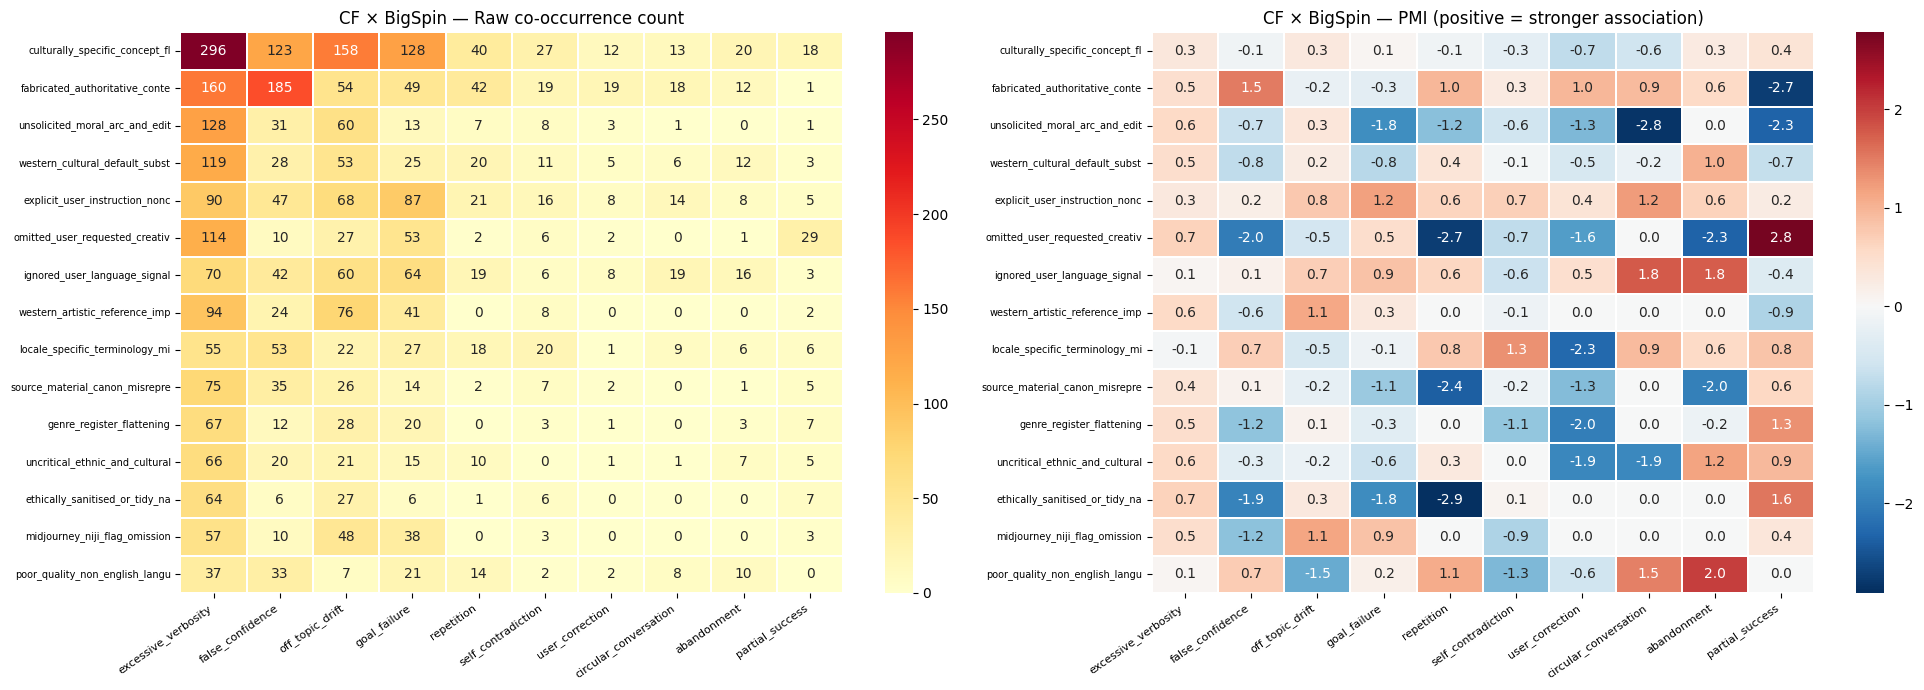

In [55]:
N = len(merged)
bs_counts  = Counter(sig for m in merged for sig in m['bigspin_signals'])
cf_type_counts = Counter(ft for m in merged for ft in m['cultural_failure_types'])

# Co-occurrence and PMI
cf_bs_cooc = defaultdict(Counter)
bs_cf_cooc = defaultdict(Counter)
for m in merged:
    for cf in m['cultural_failure_types']:
        for bs in m['bigspin_signals']:
            cf_bs_cooc[cf][bs] += 1
            bs_cf_cooc[bs][cf] += 1

# PMI: log2(P(cf,bs) / (P(cf)*P(bs)))
top_cf = [ft for ft,_ in ft_counts.most_common(15)]
top_bs = [sig for sig,_ in bs_counts.most_common(10)]

raw_matrix = np.zeros((len(top_cf), len(top_bs)))
pmi_matrix = np.zeros((len(top_cf), len(top_bs)))
for i, cf in enumerate(top_cf):
    for j, bs in enumerate(top_bs):
        n_joint = cf_bs_cooc[cf][bs]
        raw_matrix[i,j] = n_joint
        if n_joint > 0:
            p_joint = n_joint / N
            p_cf    = cf_type_counts[cf] / N
            p_bs    = bs_counts[bs] / N
            pmi_matrix[i,j] = math.log2(p_joint / (p_cf * p_bs))

# Top pairings by raw count
print('=== Top cultural failure ↔ BigSpin signal pairings (raw count) ===')
pairs = sorted([(cf,bs,cf_bs_cooc[cf][bs])
                for cf in top_cf for bs in top_bs
                if cf_bs_cooc[cf][bs]>=2], key=lambda x:-x[2])
print(f'  {"Cultural failure":<50}  {"BigSpin signal":<28}  {"N":>4}')
print('  '+'-'*86)
for cf,bs,n in pairs[:20]:
    print(f'  {cf:<50}  {bs:<28}  {n:>4}')

print()

# Bidirectional: for each CF type, top BS signals
print('=== For each CF type: top BigSpin signals ===')
for cf, cnt in ft_counts.most_common(10):
    bs_top = cf_bs_cooc[cf].most_common(3)
    bs_str = '  |  '.join(f'{s} ({n})' for s,n in bs_top) or '(none)'
    print(f'  [{cf}] total={cnt}')
    print(f'    → {bs_str}')

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
short_cf = [ft[:30] for ft in top_cf]

sns.heatmap(raw_matrix, xticklabels=top_bs, yticklabels=short_cf,
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], linewidths=0.3)
axes[0].set_title('CF × BigSpin — Raw co-occurrence count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=7)

sns.heatmap(pmi_matrix, xticklabels=top_bs, yticklabels=short_cf,
            annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[1], linewidths=0.3)
axes[1].set_title('CF × BigSpin — PMI (positive = stronger association)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'D_cf_bigspin_cooccurrence.png', dpi=150)
plt.show()

findings['cooccurrence'] = {
    'top_pairs': pairs[:10],
    'pmi_max': float(pmi_matrix.max()),
}

## 11. Turn-Level Alignment + Severity Escalation

Total turn-positioned tags: 3619
  Avg absolute turn of cultural failure: 0.9
  Avg relative position (0=start, 1=end): 0.10

  Severity 1: avg turn 1.0  (n=730)
  Severity 2: avg turn 0.8  (n=2529)
  Severity 3: avg turn 1.0  (n=352)
  Severity 4: avg turn 0.2  (n=8)

=== Severity escalation (convs with ≥2 failure tags, n=783) ===
  Escalating (severity rises):  43 (5.5%)
  Flat (same severity):         305        (39.0%)
  Falling (severity drops):     435     (55.6%)


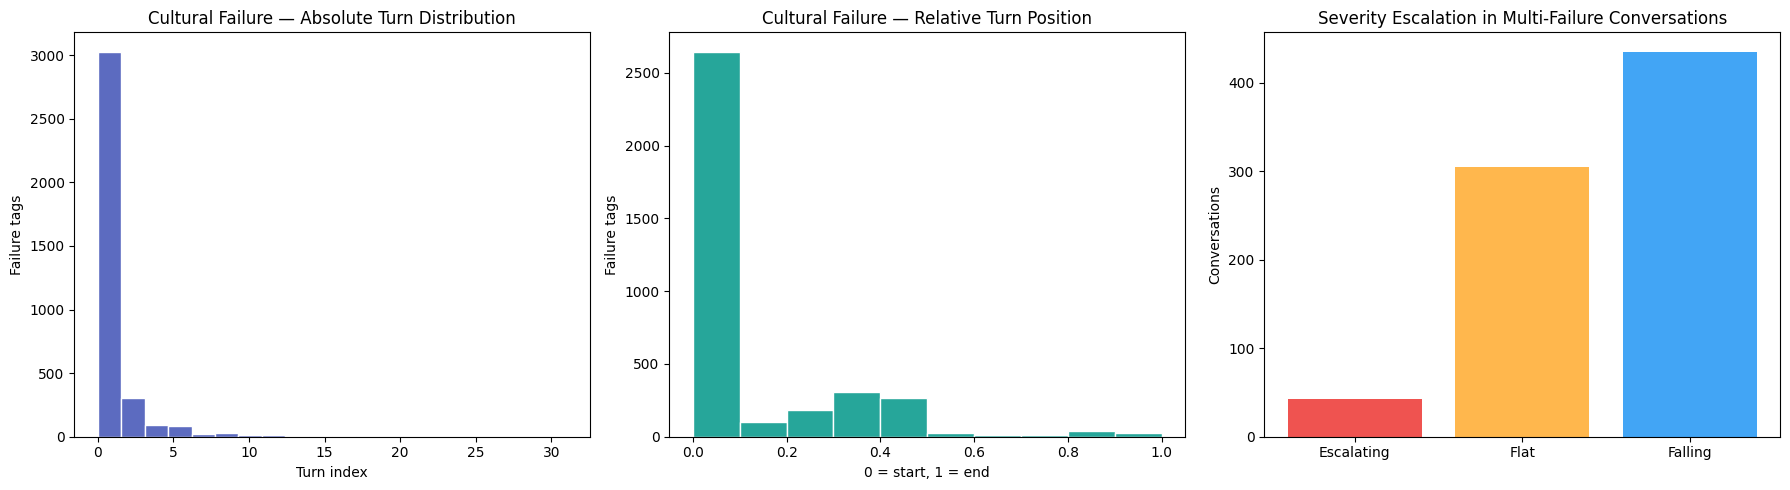

In [57]:
# ── Turn-level alignment: where in conversation do cultural failures occur? ───
cf_turns_all = []   # (turn_index, num_turns, severity)
for m in merged:
    num_t = m['num_turns']
    for tag in m['cf_tags']:
        turn_idx = getattr(tag, 'turn', 0)
        sev      = getattr(tag, 'cultural_failure_severity', 1)
        cf_turns_all.append({'turn': turn_idx, 'num_turns': num_t, 'sev': sev,
                             'rel_pos': turn_idx / max(num_t-1, 1)})

print(f'Total turn-positioned tags: {len(cf_turns_all)}')
if cf_turns_all:
    avg_turn = sum(t['turn'] for t in cf_turns_all) / len(cf_turns_all)
    avg_rel  = sum(t['rel_pos'] for t in cf_turns_all) / len(cf_turns_all)
    print(f'  Avg absolute turn of cultural failure: {avg_turn:.1f}')
    print(f'  Avg relative position (0=start, 1=end): {avg_rel:.2f}')
    print()

    # Turn distribution by severity
    for s in [1,2,3,4]:
        grp = [t['turn'] for t in cf_turns_all if t['sev']==s]
        if grp:
            print(f'  Severity {s}: avg turn {sum(grp)/len(grp):.1f}  (n={len(grp)})')

# ── Severity escalation: for multi-failure convs, do severities rise? ─────────
escalating, flat, falling = 0, 0, 0
for t in A_tags:
    tags_sorted = sorted(t.cultural_failures, key=lambda x: x.turn)
    sevs = [tag.cultural_failure_severity for tag in tags_sorted]
    if len(sevs) >= 2:
        if sevs[-1] > sevs[0]:   escalating += 1
        elif sevs[-1] < sevs[0]: falling    += 1
        else:                     flat       += 1

multi = escalating + flat + falling
print(f'\n=== Severity escalation (convs with ≥2 failure tags, n={multi}) ===')
if multi:
    print(f'  Escalating (severity rises):  {escalating} ({escalating/multi*100:.1f}%)')
    print(f'  Flat (same severity):         {flat}        ({flat/multi*100:.1f}%)')
    print(f'  Falling (severity drops):     {falling}     ({falling/multi*100:.1f}%)')

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if cf_turns_all:
    turns_abs = [t['turn'] for t in cf_turns_all]
    axes[0].hist(turns_abs, bins=20, color='#5c6bc0', edgecolor='white')
    axes[0].set_title('Cultural Failure — Absolute Turn Distribution')
    axes[0].set_xlabel('Turn index'); axes[0].set_ylabel('Failure tags')

    rel_pos = [t['rel_pos'] for t in cf_turns_all]
    axes[1].hist(rel_pos, bins=10, color='#26a69a', edgecolor='white')
    axes[1].set_title('Cultural Failure — Relative Turn Position')
    axes[1].set_xlabel('0 = start, 1 = end'); axes[1].set_ylabel('Failure tags')

if multi:
    axes[2].bar(['Escalating','Flat','Falling'], [escalating, flat, falling],
                color=['#ef5350','#ffb74d','#42a5f5'])
    axes[2].set_title('Severity Escalation in Multi-Failure Conversations')
    axes[2].set_ylabel('Conversations')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'E_turn_alignment.png', dpi=150)
plt.show()

findings['turn_alignment'] = {
    'avg_turn': avg_turn if cf_turns_all else None,
    'avg_rel_pos': avg_rel if cf_turns_all else None,
    'escalating': escalating, 'flat': flat, 'falling': falling,
}

## 12. Recovery + User Response to Cultural Failure

=== Recovery rates (ai_self_correction / recovery signal) ===
  With cultural failure    (n=798):    2.9% have recovery signal
  Without cultural failure (n=27): 3.7% have recovery signal

=== User reaction signals ===
  Signal                            CF present     CF absent   Rate diff
  --------------------------------------------------------------------
  abandonment                             3.6%          7.4%       -3.8pp
  clarification_request                   0.3%          0.0%       +0.3pp
  explicit_frustration                    0.9%          0.0%       +0.9pp
  negative_sentiment_shift                1.0%          0.0%       +1.0pp
  scope_narrowing                         0.9%          0.0%       +0.9pp
  user_correction                         2.6%          3.7%       -1.1pp

  Abandonment rate: CF=3.6%  no-CF=7.4%


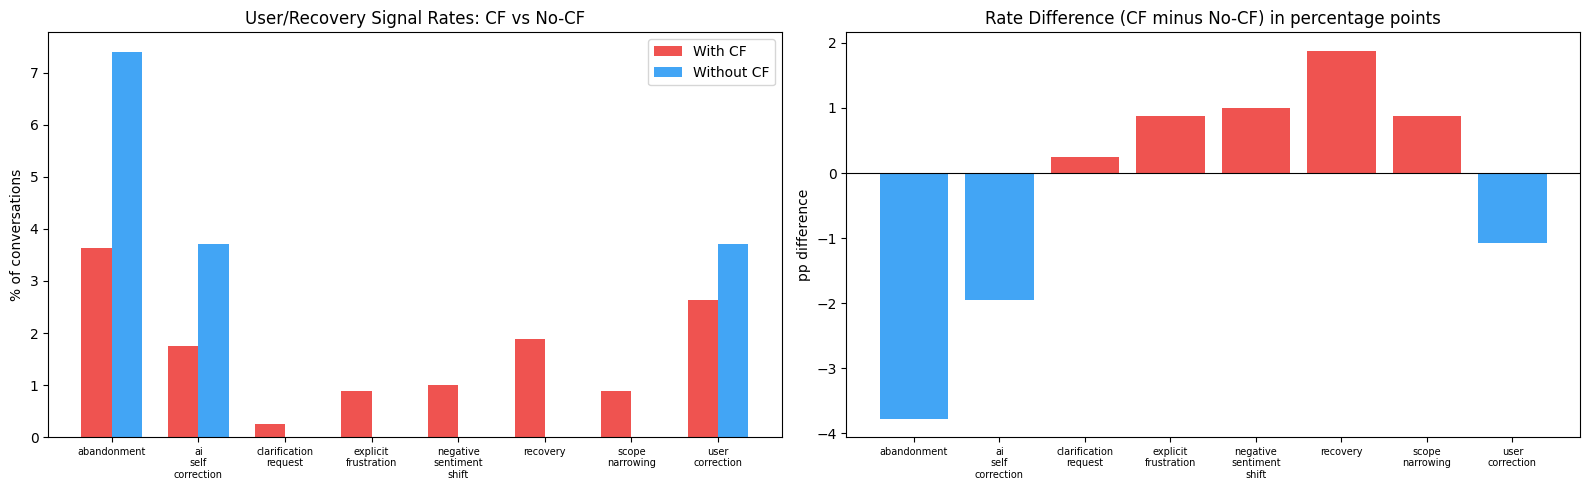

In [58]:
RECOVERY_SIGS  = {'ai_self_correction', 'recovery'}
USER_REACT_SIGS = {'user_correction', 'explicit_frustration', 'negative_sentiment_shift',
                   'clarification_request', 'abandonment', 'scope_narrowing'}

def has_sig(m, sig_set):
    return bool(set(m['bigspin_signals']) & sig_set)

cf_m     = [m for m in merged if m['has_cultural_failures']]
no_cf_m  = [m for m in merged if m['has_cultural_failures'] is False]

recovery_cf    = sum(1 for m in cf_m    if has_sig(m, RECOVERY_SIGS))
recovery_no_cf = sum(1 for m in no_cf_m if has_sig(m, RECOVERY_SIGS))

print('=== Recovery rates (ai_self_correction / recovery signal) ===')
print(f'  With cultural failure    (n={len(cf_m)}):    {recovery_cf/max(len(cf_m),1)*100:.1f}% have recovery signal')
print(f'  Without cultural failure (n={len(no_cf_m)}): {recovery_no_cf/max(len(no_cf_m),1)*100:.1f}% have recovery signal')
print()

print('=== User reaction signals ===')
print(f'  {"Signal":<30}  {"CF present":>12}  {"CF absent":>12}  {"Rate diff":>10}')
print('  ' + '-'*68)
for sig in sorted(USER_REACT_SIGS):
    r_cf    = sum(1 for m in cf_m    if sig in m['bigspin_signals']) / max(len(cf_m),1) * 100
    r_no_cf = sum(1 for m in no_cf_m if sig in m['bigspin_signals']) / max(len(no_cf_m),1) * 100
    print(f'  {sig:<30}  {r_cf:>11.1f}%  {r_no_cf:>11.1f}%  {r_cf-r_no_cf:>+9.1f}pp')
print()

# Abandonment rate specifically
aban_cf    = sum(1 for m in cf_m    if 'abandonment' in m['bigspin_signals'])
aban_no_cf = sum(1 for m in no_cf_m if 'abandonment' in m['bigspin_signals'])
print(f'  Abandonment rate: CF={aban_cf/max(len(cf_m),1)*100:.1f}%  no-CF={aban_no_cf/max(len(no_cf_m),1)*100:.1f}%')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sigs_to_plot = sorted(USER_REACT_SIGS | RECOVERY_SIGS)
r_cf_vals    = [sum(1 for m in cf_m    if s in m['bigspin_signals'])/max(len(cf_m),1)*100  for s in sigs_to_plot]
r_nocf_vals  = [sum(1 for m in no_cf_m if s in m['bigspin_signals'])/max(len(no_cf_m),1)*100 for s in sigs_to_plot]
x = np.arange(len(sigs_to_plot)); w = 0.35
axes[0].bar(x-w/2, r_cf_vals,   w, label='With CF',    color='#ef5350')
axes[0].bar(x+w/2, r_nocf_vals, w, label='Without CF', color='#42a5f5')
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.replace('_','\n') for s in sigs_to_plot], fontsize=7)
axes[0].set_title('User/Recovery Signal Rates: CF vs No-CF')
axes[0].set_ylabel('% of conversations'); axes[0].legend()

# Diff plot
diffs = [c-n for c,n in zip(r_cf_vals, r_nocf_vals)]
colors = ['#ef5350' if d>0 else '#42a5f5' for d in diffs]
axes[1].bar([s.replace('_','\n') for s in sigs_to_plot], diffs, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Rate Difference (CF minus No-CF) in percentage points')
axes[1].set_ylabel('pp difference')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'F_recovery_user_response.png', dpi=150)
plt.show()

findings['recovery'] = {
    'recovery_rate_cf':    recovery_cf/max(len(cf_m),1)*100,
    'recovery_rate_no_cf': recovery_no_cf/max(len(no_cf_m),1)*100,
    'abandonment_rate_cf': aban_cf/max(len(cf_m),1)*100,
}

## 13. Country Clustering + Isolated `goal_failure`

=== Isolated goal_failure (only BigSpin signal) + cultural failure ===
  Cultural failure + goal_failure (any signals): 192
  Cultural failure + ONLY goal_failure:          16

  Cultural failure types in isolated goal_failure cases:
    explicit_user_instruction_noncompliance: 5
    culturally_specific_concept_flattened_to_generic: 5
    overcautious_or_unexplained_refusal_of_legitimate_requests: 4
    omitted_user_requested_creative_elements: 3
    ignored_user_language_signal: 3
    jurisdiction_agnostic_legal_and_professional_advice: 3
    unsolicited_moral_arc_and_editorial_intrusion: 3
    genre_register_flattening: 2
    western_cultural_default_substitution: 2
    incomplete_or_truncated_output: 2
    cross_cultural_naming_and_honorific_errors: 1
    locale_specific_terminology_mistranslated_or_ignored: 1
    religious_and_scholarly_tradition_mishandled: 1
    western_artistic_reference_imposed_on_non_western_subject: 1
    midjourney_niji_flag_omission: 1

  BigSpin quality in

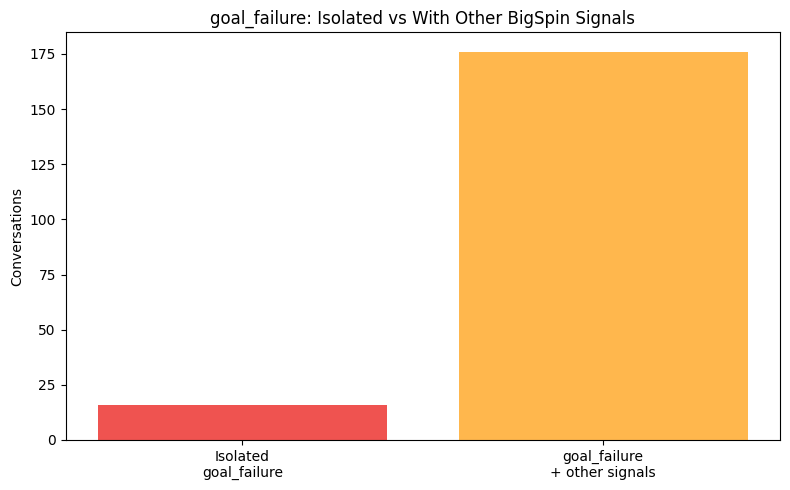

In [60]:
# ── Isolated goal_failure ─────────────────────────────────────────────────────
isolated_gf = [m for m in merged
               if m['has_cultural_failures']
               and m['bigspin_signals'] == ['goal_failure']]

gf_with_cf  = [m for m in merged
               if m['has_cultural_failures']
               and 'goal_failure' in m['bigspin_signals']]

print(f'=== Isolated goal_failure (only BigSpin signal) + cultural failure ===')
print(f'  Cultural failure + goal_failure (any signals): {len(gf_with_cf)}')
print(f'  Cultural failure + ONLY goal_failure:          {len(isolated_gf)}')
print()
igf_ft = Counter(ft for m in isolated_gf for ft in m['cultural_failure_types'])
print('  Cultural failure types in isolated goal_failure cases:')
for ft, cnt in igf_ft.most_common(15):
    print(f'    {ft}: {cnt}')
print()
print('  BigSpin quality in isolated cases:')
for q in ['good','acceptable','poor','critical']:
    n = sum(1 for m in isolated_gf if m['bigspin_quality']==q)
    if n: print(f'    {q}: {n}')
print()

# ── Detailed examples ─────────────────────────────────────────────────────────
print('=== Examples: isolated goal_failure + cultural failure ===')
for m in isolated_gf[:5]:
    cid = m['conversation_id']
    rec = rec_by_id.get(cid)
    tag = tag_by_id.get(cid)
    if not rec or not tag: continue
    print(f'\nconv_id={cid}  turns={m["num_turns"]}  quality={m["bigspin_quality"]}')
    print(f'Cultural summary: {tag.cultural_summary}')
    for t in tag.cultural_failures:
        print(f'  [turn {t.turn}] {t.failure_type} (sev={t.cultural_failure_severity})')
        print(f'    "{t.evidence[:100]}"')
    print('  --- Conversation ---')
    for i, turn in enumerate(rec.conversation.turns):
        role = turn.role.upper()
        txt  = turn.content[:200].replace('\n',' ')
        ell  = '…' if len(turn.content) > 200 else ''
        print(f'    [{i+1}] {role}: {txt}{ell}')
    print('-'*60)

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Isolated\ngoal_failure', 'goal_failure\n+ other signals'],
       [len(isolated_gf), len(gf_with_cf) - len(isolated_gf)],
       color=['#ef5350', '#ffb74d'])
ax.set_title('goal_failure: Isolated vs With Other BigSpin Signals')
ax.set_ylabel('Conversations')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'G_isolated_goalfailure.png', dpi=150)
plt.show()

findings['isolated_goal_failure'] = {
    'total': len(isolated_gf),
    'top_cf_types': igf_ft.most_common(5),
}

## 14. Export Full Report (Text + PDF)

In [71]:
from collections import Counter, defaultdict
from datetime import datetime
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 HRFlowable, Image, PageBreak, Table, TableStyle)
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER

REPORT_PDF = OUTPUT_DIR / 'bigspin_cultural_report.pdf'
now = datetime.now().strftime('%Y-%m-%d %H:%M')

# ── Styles ────────────────────────────────────────────────────────────────────
styles  = getSampleStyleSheet()
s_title = ParagraphStyle('Title2', parent=styles['Title'],   fontSize=16, spaceAfter=6, alignment=TA_CENTER)
s_h1    = ParagraphStyle('H1',     parent=styles['Heading1'],fontSize=11, spaceBefore=12, spaceAfter=4, textColor=colors.HexColor('#1a237e'))
s_h2    = ParagraphStyle('H2',     parent=styles['Heading2'],fontSize=9,  spaceBefore=8,  spaceAfter=3, textColor=colors.HexColor('#283593'))
s_body  = ParagraphStyle('Body',   parent=styles['Normal'],  fontSize=8,  leading=11)
s_mono  = ParagraphStyle('Mono',   parent=styles['Normal'],  fontSize=7,  leading=9.5, fontName='Courier')
s_small = ParagraphStyle('Small',  parent=styles['Normal'],  fontSize=6.5,leading=9,   fontName='Courier', textColor=colors.HexColor('#424242'))
s_cap   = ParagraphStyle('Cap',    parent=styles['Normal'],  fontSize=7.5,leading=10,  alignment=TA_CENTER, textColor=colors.HexColor('#616161'))

PW = A4[0] - 36*mm  # usable page width

def safe(t):
    return str(t).replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')

def add_chart(story, path, caption, width_mm=160):
    p = OUTPUT_DIR / path
    if p.exists():
        story.append(Spacer(1, 3*mm))
        story.append(Image(str(p), width=width_mm*mm, height=width_mm*mm*0.55))
        story.append(Paragraph(caption, s_cap))
        story.append(Spacer(1, 4*mm))

def add_example(story, m, tag, rec):
    """Render one conversation example with cultural failure tags — no truncation."""
    story.append(Paragraph(
        f'conv_id={safe(m["conversation_id"])}  '
        f'turns={m["num_turns"]}  quality={safe(m["bigspin_quality"])}',
        s_h2))
    story.append(Paragraph(safe(tag.cultural_summary), s_body))
    story.append(Spacer(1, 2*mm))
    for t in tag.cultural_failures:
        story.append(Paragraph(
            f'[turn {t.turn}] <b>{safe(t.failure_type)}</b>  severity={t.cultural_failure_severity}',
            s_body))
        story.append(Paragraph(f'&nbsp;&nbsp;"{safe(t.evidence)}"', s_small))
    story.append(Spacer(1, 2*mm))
    story.append(Paragraph('<b>Conversation:</b>', s_body))
    for i, turn in enumerate(rec.conversation.turns):
        role = turn.role.upper()
        story.append(Paragraph(f'[{i+1}] <b>{role}:</b> {safe(turn.content)}', s_small))
    story.append(HRFlowable(width='100%', thickness=0.4, color=colors.grey, spaceAfter=4))

# ── Self-contained computations (independent of prior cells) ─────────────────
_visible_m   = [m for m in merged if m['has_cultural_failures'] and m['bigspin_signal_count'] > 0]
_cf_m        = [m for m in merged if m['has_cultural_failures']]
_no_cf_m     = [m for m in merged if m['has_cultural_failures'] is False]
_isolated_gf = [m for m in merged
                if m['has_cultural_failures'] and m['bigspin_signals'] == ['goal_failure']]
_RECOVERY_SIGS = {'ai_self_correction', 'recovery'}

_avg_sigs_rel  = sum(m['bigspin_signal_count'] for m in rel_m)  / max(len(rel_m), 1)
_avg_sigs_neut = sum(m['bigspin_signal_count'] for m in neut_m) / max(len(neut_m), 1)
_recovery_cf    = sum(1 for m in _cf_m    if set(m['bigspin_signals']) & _RECOVERY_SIGS)
_recovery_no_cf = sum(1 for m in _no_cf_m if set(m['bigspin_signals']) & _RECOVERY_SIGS)
_aban_cf        = sum(1 for m in _cf_m    if 'abandonment' in m['bigspin_signals'])

# Co-occurrence top pairs
_bs_counts   = Counter(sig for m in merged for sig in m['bigspin_signals'])
_cf_bs_cooc  = defaultdict(Counter)
for _m in merged:
    for _cf in _m['cultural_failure_types']:
        for _bs in _m['bigspin_signals']:
            _cf_bs_cooc[_cf][_bs] += 1
_top_cf = [ft for ft,_ in ft_counts.most_common(15)]
_top_bs = [sig for sig,_ in _bs_counts.most_common(10)]
_cooc_pairs = sorted(
    [(_cf,_bs,_cf_bs_cooc[_cf][_bs]) for _cf in _top_cf for _bs in _top_bs
     if _cf_bs_cooc[_cf][_bs] >= 2], key=lambda x: -x[2])[:10]

# Turn alignment
_cf_turns_all = []
for _m in merged:
    for _tag in _m['cf_tags']:
        _cf_turns_all.append({'turn': getattr(_tag,'turn',0),
                              'rel_pos': getattr(_tag,'turn',0)/max(_m['num_turns']-1,1),
                              'sev': getattr(_tag,'cultural_failure_severity',1)})
_avg_turn    = sum(t['turn'] for t in _cf_turns_all)/len(_cf_turns_all) if _cf_turns_all else None
_avg_rel_pos = sum(t['rel_pos'] for t in _cf_turns_all)/len(_cf_turns_all) if _cf_turns_all else None
_esc, _flat, _fall = 0, 0, 0
for _t in A_tags:
    _sevs = [_tg.cultural_failure_severity for _tg in sorted(_t.cultural_failures, key=lambda x: x.turn)]
    if len(_sevs) >= 2:
        if _sevs[-1] > _sevs[0]:   _esc  += 1
        elif _sevs[-1] < _sevs[0]: _fall += 1
        else:                       _flat += 1

# Severity progression cross-tab (OA → tagging)
_sp_cross = defaultdict(lambda: defaultdict(int))
_oa_by_id = {a.conversation_id: a for a in A_open}
for _cid in set(str(k) for k in _oa_by_id) & set(tag_by_id):
    _oa  = _oa_by_id.get(_cid)
    _tag = tag_by_id.get(_cid)
    if not _oa or not _tag: continue
    _oa_sev  = _oa.overall_severity or 'none'
    _tag_max = max((t.cultural_failure_severity for t in _tag.cultural_failures), default=0)
    _sp_cross[_oa_sev][_tag_max] += 1

# ── Build story ───────────────────────────────────────────────────────────────
story = []

# Cover
story.append(Spacer(1, 20*mm))
story.append(Paragraph('BigSpin × CultureScope', s_title))
story.append(Paragraph('Cultural Failure Analysis Report', s_title))
story.append(Spacer(1, 6*mm))
story.append(Paragraph(f'Generated: {now}  |  Model: {MODEL} via {BACKEND}', s_cap))
story.append(Paragraph(f'Dataset: wildchat_bigspin_annotations_2k_opus_v1.json', s_cap))
story.append(PageBreak())

# 1. Dataset overview
story.append(Paragraph('1. Dataset Overview', s_h1))
qc = Counter(r.overall_quality for r in records)
rows = [['Quality', 'Count', '%']]
for q in ['good','acceptable','poor','critical']:
    cnt = qc.get(q,0)
    rows.append([q, str(cnt), f'{cnt/len(records)*100:.1f}%'])
rows.append(['Total', str(len(records)), ''])
t = Table(rows, colWidths=[40*mm, 30*mm, 25*mm])
t.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0), colors.HexColor('#e8eaf6')),
    ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
    ('FONTSIZE',(0,0),(-1,-1),8),
    ('GRID',(0,0),(-1,-1),0.4,colors.grey),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white, colors.HexColor('#f5f5f5')]),
]))
story.append(t)
story.append(Spacer(1,3*mm))
add_chart(story, 'bigspin_overview.png', 'Figure 1. BigSpin dataset overview — quality, signals, turn distribution')

# 2. Cultural relevance
story.append(Paragraph('2. Cultural Relevance Annotation', s_h1))
story.append(Paragraph(
    f'Of <b>{len(A_results)}</b> annotated conversations, '
    f'<b>{len(A_relevant)} ({len(A_relevant)/len(A_results)*100:.1f}%)</b> are culturally relevant '
    f'and <b>{len(A_results)-len(A_relevant)}</b> are neutral.', s_body))
story.append(Spacer(1,2*mm))
l2 = Counter()
for ann in A_relevant:
    for d in ann.relevant_dimensions:
        if d.dimension_key in CULTURAL_DIMENSIONS:
            parts = [x.strip() for x in CULTURAL_DIMENSIONS[d.dimension_key].category.split('>')]
            l2[parts[1] if len(parts) > 1 else 'Unknown'] += 1
rows2 = [['Layer-2 Category', 'Dimension mentions']]
for cat, cnt in l2.most_common():
    rows2.append([cat, str(cnt)])
t2 = Table(rows2, colWidths=[80*mm, 40*mm])
t2.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
    ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
    ('FONTSIZE',(0,0),(-1,-1),8),
    ('GRID',(0,0),(-1,-1),0.4,colors.grey),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white, colors.HexColor('#f5f5f5')]),
]))
story.append(t2)

# 3. Open-ended analysis
story.append(Paragraph('3. Open-Ended Cultural Failure Analysis (Pass 1)', s_h1))
if A_open:
    sev_obs = Counter(obs.severity for oa in A_open for obs in oa.observations)
    story.append(Paragraph(
        f'<b>{len(A_open)}</b> conversations analysed. '
        f'<b>{len(A_with_issues)} ({len(A_with_issues)/len(A_open)*100:.1f}%)</b> have issues.', s_body))
    rows3 = [['Severity','Count']] + [[s, str(sev_obs.get(s,0))] for s in ['critical','high','medium','low']]
    t3 = Table(rows3, colWidths=[40*mm,30*mm])
    t3.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
                             ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
                             ('FONTSIZE',(0,0),(-1,-1),8),('GRID',(0,0),(-1,-1),0.4,colors.grey)]))
    story.append(t3)

# 4. Synthesis
story.append(Paragraph('4. Emergent Failure Patterns (Synthesis)', s_h1))
if A_syn:
    story.append(Paragraph(safe(A_syn.synthesis_summary), s_body))
    story.append(Spacer(1,2*mm))
    rows4 = [['#','Pattern','Obs','Tags','S1','S2','S3','S4']]
    for i, pat in enumerate(sorted(A_syn.patterns, key=lambda x:-x.frequency),1):
        tc = ft_counts.get(pat.name,0)
        s  = pat_sev.get(pat.name, Counter())
        rows4.append([str(i), pat.name, str(pat.frequency), str(tc),
                      str(s.get(1,0)), str(s.get(2,0)), str(s.get(3,0)), str(s.get(4,0))])
    t4 = Table(rows4, colWidths=[8*mm,80*mm,14*mm,14*mm,10*mm,10*mm,10*mm,10*mm])
    t4.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
                             ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
                             ('FONTSIZE',(0,0),(-1,-1),6.5),('GRID',(0,0),(-1,-1),0.3,colors.grey),
                             ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,colors.HexColor('#f5f5f5')])]))
    story.append(t4)
story.append(PageBreak())

# 5. Fine-grained tagging
story.append(Paragraph('5. Fine-Grained Cultural Failure Tagging', s_h1))
sv = sum(sev_counts.values())
story.append(Paragraph(
    f'<b>{len(A_tags)}</b> conversations tagged. '
    f'<b>{len(A_with_cf)} ({len(A_with_cf)/max(len(A_tags),1)*100:.1f}%)</b> have cultural failures. '
    f'<b>{len(all_tags)}</b> total failure tags (severity sum verified: '
    f'{"✓" if sv==len(all_tags) else "MISMATCH"}).', s_body))
story.append(Spacer(1,2*mm))
add_chart(story, 'A_core_tag_stats.png', 'Figure 3. Severity distribution, top failure types, top cultural dimensions')
rows5 = [['Failure type','N','S1','S2','S3','S4']]
for ft, cnt in ft_counts.most_common(20):
    s = pat_sev[ft]
    rows5.append([ft, str(cnt), str(s.get(1,0)), str(s.get(2,0)), str(s.get(3,0)), str(s.get(4,0))])
t5 = Table(rows5, colWidths=[95*mm,14*mm,10*mm,10*mm,10*mm,10*mm])
t5.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
                         ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
                         ('FONTSIZE',(0,0),(-1,-1),6.5),('GRID',(0,0),(-1,-1),0.3,colors.grey),
                         ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,colors.HexColor('#f5f5f5')])]))
story.append(t5)
story.append(PageBreak())

# 5b. Severity Progression — Open Analysis → Tagging
story.append(Paragraph('5b. Severity Progression: Open Analysis → Fine-Grained Tagging', s_h1))
cross = {oa_s: dict(_sp_cross[oa_s]) for oa_s in ['none','low','medium','high','critical']}
story.append(Paragraph(
    'Each open-analysis severity label maps to a range of fine-grained tag severity scores. '
    'The diagonal concentration confirms good pipeline consistency — conversations flagged '
    '<b>critical</b> in pass 1 all receive tag severity 3–4 in pass 2.', s_body))
story.append(Spacer(1, 2*mm))

# Cross-tab table
oa_labels  = ['none','low','medium','high','critical']
tag_labels = ['0','1','2','3','4']
rows_sp = [['OA → Tag'] + tag_labels + ['Total']]
for oa_s in oa_labels:
    row_d = cross.get(oa_s, {})
    vals  = [row_d.get(int(t), row_d.get(t, 0)) for t in tag_labels]
    rows_sp.append([oa_s] + [str(v) for v in vals] + [str(sum(vals))])
t_sp = Table(rows_sp, colWidths=[28*mm,18*mm,18*mm,18*mm,18*mm,18*mm,18*mm])
t_sp.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
    ('BACKGROUND',(0,0),(0,-1),colors.HexColor('#e8eaf6')),
    ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
    ('FONTNAME',(0,0),(0,-1),'Helvetica-Bold'),
    ('FONTSIZE',(0,0),(-1,-1),8),
    ('GRID',(0,0),(-1,-1),0.4,colors.grey),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white, colors.HexColor('#f5f5f5')]),
    ('BACKGROUND',(5,5),(5,5),colors.HexColor('#ffcdd2')),  # critical→sev4 cell highlight
]))
story.append(t_sp)
story.append(Spacer(1, 2*mm))
add_chart(story, 'H_severity_progression.png',
          'Figure H. Heatmap: open-analysis severity (rows) vs max fine-grained tag severity (cols)', width_mm=130)

# Critical examples — type 1: harmful_content_produced_under_fictional_framing
story.append(Paragraph('Critical Failures — harmful_content_produced_under_fictional_framing', s_h2))
story.append(Paragraph(
    'Conversations where the assistant generated content harmful under fictional framing '
    '(sev=4). Two worst-case examples:', s_body))
story.append(Spacer(1, 2*mm))
shown_hc = 0
for cid in ['405813', '241253']:
    rec = rec_by_id.get(cid)
    tag = tag_by_id.get(cid)
    if not rec or not tag: continue
    m = next((x for x in merged if x['conversation_id'] == cid), None)
    if m:
        add_example(story, m, tag, rec)
    shown_hc += 1

story.append(PageBreak())
# Critical examples — type 2: non_consensual_dynamics_normalised_through_narrative
story.append(Paragraph('Critical Failures — non_consensual_dynamics_normalised_through_narrative', s_h2))
story.append(Paragraph(
    'Conversations where non-consensual dynamics were normalised through narrative framing '
    '(sev=4). Two worst-case examples:', s_body))
story.append(Spacer(1, 2*mm))
for cid in ['144067', '493954']:
    rec = rec_by_id.get(cid)
    tag = tag_by_id.get(cid)
    if not rec or not tag: continue
    m = next((x for x in merged if x['conversation_id'] == cid), None)
    if m:
        add_example(story, m, tag, rec)
story.append(PageBreak())

# 6. BigSpin × Cultural
story.append(Paragraph('6. BigSpin × Cultural Failure Rates', s_h1))
story.append(Paragraph(
    f'Culturally-relevant conversations have a BigSpin failure rate of '
    f'<b>{failure_rate(rel_m):.1f}%</b> vs '
    f'<b>{failure_rate(neut_m):.1f}%</b> for neutral conversations. '
    f'Average signals/conv: relevant <b>{_avg_sigs_rel:.2f}</b>, '
    f'neutral <b>{_avg_sigs_neut:.2f}</b>.', s_body))
add_chart(story, 'B_bigspin_cultural_rates.png', 'Figure 4. Cultural failure rate by BigSpin quality; BigSpin failure rate by cultural relevance')

# 7. Blind spots
story.append(Paragraph('7. Blind Spots — Cultural Failures BigSpin Misses', s_h1))
story.append(Paragraph(
    f'Of <b>{len(A_with_cf)}</b> conversations with cultural failures, '
    f'<b>{len(invisible_m)} ({len(invisible_m)/max(len(A_with_cf),1)*100:.1f}%)</b> '
    f'have <b>zero BigSpin signals</b> — completely invisible to existing evaluation. '
    f'<b>{len(_visible_m)}</b> are detectable by BigSpin.', s_body))
add_chart(story, 'C_blind_spots.png', 'Figure 5. Cultural failure types in BigSpin-invisible cases; invisible vs visible by quality')

# 8. Co-occurrence + PMI
story.append(Paragraph('8. CF ↔ BigSpin Co-occurrence + PMI', s_h1))
add_chart(story, 'D_cf_bigspin_cooccurrence.png', 'Figure 6. Raw co-occurrence (left) and PMI (right) between cultural failure types and BigSpin signals')
cooc_pairs = _cooc_pairs
if cooc_pairs:
    rows8 = [['Cultural failure type','BigSpin signal','N']]
    for cf, bs, n in cooc_pairs:
        rows8.append([cf, bs, str(n)])
    t8 = Table(rows8, colWidths=[90*mm,50*mm,12*mm])
    t8.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,0),colors.HexColor('#e8eaf6')),
                             ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
                             ('FONTSIZE',(0,0),(-1,-1),7),('GRID',(0,0),(-1,-1),0.3,colors.grey),
                             ('ROWBACKGROUNDS',(0,1),(-1,-1),[colors.white,colors.HexColor('#f5f5f5')])]))
    story.append(t8)
story.append(PageBreak())

# 9. Turn-level alignment
story.append(Paragraph('9. Turn-Level Alignment + Severity Escalation', s_h1))
if _avg_turn is not None:
    story.append(Paragraph(
        f'Cultural failures occur at avg turn <b>{_avg_turn:.1f}</b> '
        f'(relative position <b>{_avg_rel_pos:.2f}</b>, where 0=start, 1=end). '
        f'Among multi-failure conversations: '
        f'<b>{_esc}</b> escalate, '
        f'<b>{_flat}</b> stay flat, '
        f'<b>{_fall}</b> decrease in severity.', s_body))
add_chart(story, 'E_turn_alignment.png', 'Figure 7. Absolute and relative turn position of cultural failures; severity escalation')

# 10. Recovery + user response
story.append(Paragraph('10. Recovery + User Response to Cultural Failure', s_h1))
story.append(Paragraph(
    f'Recovery signal rate: <b>{_recovery_cf/max(len(_cf_m),1)*100:.1f}%</b> with cultural failure vs '
    f'<b>{_recovery_no_cf/max(len(_no_cf_m),1)*100:.1f}%</b> without. '
    f'Abandonment rate with cultural failure: <b>{_aban_cf/max(len(_cf_m),1)*100:.1f}%</b>.', s_body))
add_chart(story, 'F_recovery_user_response.png', 'Figure 8. User/recovery signal rates with and without cultural failure; rate differences')

# 11. Isolated goal_failure + examples
story.append(Paragraph('11. Isolated goal_failure + Cultural Failure', s_h1))
story.append(Paragraph(
    f'<b>{len(_isolated_gf)}</b> conversations where BigSpin fired <b>only</b> '
    f'<code>goal_failure</code> (no other signal to explain why) AND a cultural failure was found. '
    f'These are the strongest candidates where cultural misunderstanding is the root cause of goal failure.',
    s_body))
add_chart(story, 'G_isolated_goalfailure.png', 'Figure 9. Isolated goal_failure vs goal_failure with other signals')

story.append(Paragraph('Selected Examples — Isolated goal_failure', s_h2))
shown = 0
for m in _isolated_gf:
    if shown >= 2: break
    cid = m['conversation_id']
    rec = rec_by_id.get(cid)
    tag = tag_by_id.get(cid)
    if not rec or not tag: continue
    add_example(story, m, tag, rec)
    shown += 1

# Also show 1 culturally-invisible example
story.append(PageBreak())
story.append(Paragraph('Selected Examples — Culturally-Invisible Failures', s_h2))
story.append(Paragraph(
    'These conversations have cultural failures but zero BigSpin signals — '
    'BigSpin would rate them as fine.', s_body))
story.append(Spacer(1, 2*mm))
shown = 0
for m in invisible_m:
    if shown >= 2: break
    cid = m['conversation_id']
    rec = rec_by_id.get(cid)
    tag = tag_by_id.get(cid)
    if not rec or not tag: continue
    add_example(story, m, tag, rec)
    shown += 1

# 12. Key findings
story.append(PageBreak())
story.append(Paragraph('12. Key Findings', s_h1))
kf_rows = [
    ['1', f'{len(A_relevant)}/{len(A_results)} ({len(A_relevant)/len(A_results)*100:.1f}%) annotated conversations are culturally relevant'],
    ['2', f'{len(A_with_cf)}/{len(A_tags)} ({len(A_with_cf)/max(len(A_tags),1)*100:.1f}%) relevant conversations have at least one cultural failure'],
    ['3', f'{len(all_tags)} total failure tags; severity sum verified ✓'],
    ['4', f'{len(invisible_m)} cultural failures completely invisible to BigSpin ({len(invisible_m)/max(len(A_with_cf),1)*100:.1f}%)'],
    ['5', f'Culturally-relevant convs: {failure_rate(rel_m):.1f}% BigSpin failure rate vs {failure_rate(neut_m):.1f}% neutral'],
    ['6', f'{len(A_syn.patterns) if A_syn else 0} emergent cultural failure patterns from synthesis'],
    ['7', f'{len(_isolated_gf)} conversations: BigSpin fires only goal_failure — cultural failure explains the root cause'],
    ['8', f'Recovery rate {_recovery_cf/max(len(_cf_m),1)*100:.1f}% with CF vs {_recovery_no_cf/max(len(_no_cf_m),1)*100:.1f}% without'],
]
tkf = Table(kf_rows, colWidths=[8*mm, PW-8*mm])
tkf.setStyle(TableStyle([
    ('FONTSIZE',(0,0),(-1,-1),8),('VALIGN',(0,0),(-1,-1),'TOP'),
    ('GRID',(0,0),(-1,-1),0.3,colors.lightgrey),
    ('ROWBACKGROUNDS',(0,0),(-1,-1),[colors.white,colors.HexColor('#f5f5f5')]),
    ('FONTNAME',(0,0),(0,-1),'Helvetica-Bold'),
]))
story.append(tkf)

# ── Build PDF ─────────────────────────────────────────────────────────────────
doc = SimpleDocTemplate(str(REPORT_PDF), pagesize=A4,
                        leftMargin=18*mm, rightMargin=18*mm,
                        topMargin=18*mm,  bottomMargin=18*mm)
doc.build(story)
print(f'PDF report → {REPORT_PDF}')

PDF report → ../output/bigspin/bigspin_cultural_report.pdf
